# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [42]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as mpl

In [43]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [44]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [45]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [46]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [47]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [48]:
# inspección de plans con .info()
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [49]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [50]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [51]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [52]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Se logra observar para users que "city" y "churn_date" tiene varios faltantes, sin embargo, para "city" no es nada grabe ya que solo el 11% de los datos es faltante, se recomienda imputar o dejar como nulos. En cuanto a "churn_date", tiene el 88% de datos faltantes, se recomienda eliminar.

En usage "date", "duration" y "length" tienen un porcentaje de faltantes del 0.13%, 55% y 45% respectivamente. Para "date" se recomienda dejar como nulos, para "duration" y "length" se recomienda investigar para imputar.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- "city"(11%), "churn_date"(88%), "date"(0.13%), "duration"(55%) y "length"(45%)
- Indica qué harías: ¿imputar, eliminar, ignorar?
- "city"(imputar), "churn_date"(eliminar), "date"(dejar nulos), "duration"(imputar) y "length"(imputar)

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [53]:
# explorar columnas numéricas de users
import pandas as pd
import numpy as np

print("=" * 80)
print("EXPLORACIÓN - COLUMNAS NUMÉRICAS DE USERS_LATAM")
print("=" * 80)

#  USER_ID
print("\n COLUMNA: user_id")
print("-" * 80)
print(users['user_id'].describe())
print(f"\n   Valores únicos: {users['user_id'].nunique()}")
print(f"   ¿Hay duplicados?: {users['user_id'].duplicated().any()}")
print(f"   Rango: {users['user_id'].min()} a {users['user_id'].max()}")
print(f"   Incremento: {users['user_id'].iloc[1] - users['user_id'].iloc[0]}")

#  AGE
print("\n\n COLUMNA: age")
print("-" * 80)
print(users['age'].describe())
print(f"\n   Valores únicos: {users['age'].nunique()}")
print(f"   Edades mínima y máxima: {users['age'].min()} a {users['age'].max()}")
print(f"\n   Distribución por rango de edad:")
print(f"   - 18-25 años: {(users['age'] <= 25).sum()}")
print(f"   - 26-35 años: {((users['age'] > 25) & (users['age'] <= 35)).sum()}")
print(f"   - 36-50 años: {((users['age'] > 35) & (users['age'] <= 50)).sum()}")
print(f"   - 51+ años: {(users['age'] > 50).sum()}")


EXPLORACIÓN - COLUMNAS NUMÉRICAS DE USERS_LATAM

 COLUMNA: user_id
--------------------------------------------------------------------------------
count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

   Valores únicos: 4000
   ¿Hay duplicados?: False
   Rango: 10000 a 13999
   Incremento: 1


 COLUMNA: age
--------------------------------------------------------------------------------
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

   Valores únicos: 63
   Edades mínima y máxima: -999 a 79

   Distribución por rango de edad:
   - 18-25 años: 544
   - 26-35 años: 689
   - 36-50 años: 988
   - 51+ años: 1779


- La columna `user_id` 4000 valores únicos (sin duplicados), Rango: 10000-13999 (incremental), Distribución uniforme
- La columna `age` REQUIERE LIMPIEZA
Media 33.74 años (inflada por -999)
Mediana	47 años (Más confiable)
Min	-999 
Max	79 años
Valores únicos	63

In [54]:
import pandas as pd
import numpy as np


print("=" * 80)
print("EXPLORACIÓN COMPLETA - USAGE.CSV")
print("=" * 80)

# ID
print("\n COLUMNA: id")
print("-" * 80)
print(usage['id'].describe())
print(f"\n   Valores únicos: {usage['id'].nunique()}")
print(f"   ¿Hay duplicados?: {usage['id'].duplicated().any()}")
print(f"   Rango: {usage['id'].min()} a {usage['id'].max()}")

#  USER_ID
print("\n\n COLUMNA: user_id")
print("-" * 80)
print(usage['user_id'].describe())
print(f"\n   Valores únicos: {usage['user_id'].nunique()}")
print(f"   Rango: {usage['user_id'].min()} a {usage['user_id'].max()}")

#  TYPE
print("\n\n COLUMNA: type")
print("-" * 80)
print(f"   Distribución:")
print(usage['type'].value_counts())
print(f"\n   Porcentaje:")
print(usage['type'].value_counts(normalize=True) * 100)

#  DATE
print("\n\n COLUMNA: date")
print("-" * 80)
usage['date'] = pd.to_datetime(usage['date'])
print(f"   Primer evento: {usage['date'].min()}")
print(f"   Último evento: {usage['date'].max()}")
print(f"   Valores nulos: {usage['date'].isnull().sum()}")

#  DURATION
print("\n\n COLUMNA: duration (LLAMADAS)")
print("-" * 80)
print(usage['duration'].describe())
print(f"\n   Valores nulos: {usage['duration'].isnull().sum()}")
print(f"   ¿Solo en llamadas?: {usage[usage['type'] == 'call']['duration'].isnull().sum() == 0}")
print(f"   ¿NaN en mensajes?: {usage[usage['type'] == 'text']['duration'].isnull().sum()}")

# LENGTH
print("\n\n COLUMNA: length (MENSAJES)")
print("-" * 80)
print(usage['length'].describe())
print(f"\n   Valores nulos: {usage['length'].isnull().sum()}")
print(f"   ¿Solo en mensajes?: {usage[usage['type'] == 'text']['length'].isnull().sum() == 0}")
print(f"   ¿NaN en llamadas?: {usage[usage['type'] == 'call']['length'].isnull().sum()}")

# RESUMEN GENERAL
print("\n\n RESUMEN GENERAL")
print("-" * 80)
print(f"   Total eventos: {len(usage)}")
print(f"   Usuarios únicos: {usage['user_id'].nunique()}")
print(f"   Eventos por usuario (promedio): {len(usage) / usage['user_id'].nunique():.2f}")

calls = usage[usage['type'] == 'call']
texts = usage[usage['type'] == 'text']

print(f"\n   LLAMADAS:")
print(f"   - Total: {len(calls)}")
print(f"   - Duración total (minutos): {calls['duration'].sum():.2f}")
print(f"   - Duración promedio: {calls['duration'].mean():.2f} min")
print(f"   - Duración máxima: {calls['duration'].max():.2f} min")

print(f"\n   MENSAJES:")
print(f"   - Total: {len(texts)}")
print(f"   - Caracteres total: {texts['length'].sum():.0f}")
print(f"   - Caracteres promedio: {texts['length'].mean():.2f}")
print(f"   - Caracteres máximo: {texts['length'].max():.0f}")

# VALORES NULOS GENERAL
print(f"\n\n RESUMEN DE VALORES NULOS")
print("-" * 80)
print(usage.isnull().sum())

# PRIMERAS 15 FILAS
print(f"\n\n PRIMERAS 15 FILAS (MUESTRA)")
print("-" * 80)
print(usage.head(15))

# ÚLTIMAS 5 FILAS
print(f"\n\n ÚLTIMAS 5 FILAS")
print("-" * 80)
print(usage.tail(5))



EXPLORACIÓN COMPLETA - USAGE.CSV

 COLUMNA: id
--------------------------------------------------------------------------------
count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

   Valores únicos: 40000
   ¿Hay duplicados?: False
   Rango: 1 a 40000


 COLUMNA: user_id
--------------------------------------------------------------------------------
count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64

   Valores únicos: 3999
   Rango: 10000 a 13999


 COLUMNA: type
--------------------------------------------------------------------------------
   Distribución:
text    22092
call    17908
Name: type, dtype: int64

   Porcentaje:
text    55.23
call    44.77
Name: type, dtype: float64


 COLUMNA:

- Las columnas `id` y `user_id` estan perfectas
- Las columnas 'date' no tiene 50 valores y 'duration' y 'length' tienen demasiados valores nulos

In [55]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users['city'].value_counts())
print(f"\nCiudades únicas: {users['city'].nunique()}")
print(f"Valores NULL: {users['city'].isna().sum()}")

print(users['plan'].value_counts())
print(f"\nPlanes únicos: {users['plan'].nunique()}")
print(f"Valores NULL: {users['plan'].isna().sum()}")



Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Ciudades únicas: 7
Valores NULL: 469
Basico     2595
Premium    1405
Name: plan, dtype: int64

Planes únicos: 2
Valores NULL: 0


- La columna `city` tiene 96 datos de "?" y la mayoria son de Bogotá
- La columna `plan` la gran mayoria son plan basico

In [56]:
# explorar columna categórica de usage
usage['type'] # completa el código

print(usage['type'].value_counts())
print(f"\nTipos de eventos únicos: {usage['type'].nunique()}")
print(f"Valores NULL: {usage['type'].isna().sum()}")
print(f"\nDistribución porcentual:")
print(usage['type'].value_counts(normalize=True) * 100)


text    22092
call    17908
Name: type, dtype: int64

Tipos de eventos únicos: 2
Valores NULL: 0

Distribución porcentual:
text    55.23
call    44.77
Name: type, dtype: float64


- La columna `type` tiene mayor numero de textos que de llamadas


---
✍️ **Comentario**: 
- age (users_latam) -999 como placeholder reemplazar con NULL o imputar
- date (usage.csv) 50 valores NULL Excluir del análisis o investigar causa
- duration (usage.csv) 16 calls sin duración Imputar con mediana (5.10 min) o excluir
- length (usage.csv) 12 messages sin longitud	Imputar con mediana (51.35 chars) o excluir

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [57]:
# Convertir a fecha la columna `reg_date` de users
# Convertir a datetime
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Verificar conversión
print(f"Valores NULL tras conversión: {users['reg_date'].isna().sum()}")

# Distribución por año
print("\nEventos por año:")
print(users['reg_date'].dt.year.value_counts().sort_index())

# Detectar fechas inválidas (futuras o negativas)
fecha_min = users['reg_date'].min()
fecha_max = users['reg_date'].max()
print(f"\nRango de fechas: {fecha_min} a {fecha_max}")

# Validar: no hay años futuros ni negativos
if fecha_max > pd.Timestamp('2024-12-31'):
    print("⚠️ ALERTA: Fechas futuras detectadas")
if fecha_min < pd.Timestamp('2000-01-01'):
    print("⚠️ ALERTA: Fechas muy antiguas detectadas")


Valores NULL tras conversión: 0

Eventos por año:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

Rango de fechas: 2022-01-01 00:00:00 a 2026-05-10 00:00:00
⚠️ ALERTA: Fechas futuras detectadas


In [58]:
# Convertir a fecha la columna `date` de usage
# Convertir a datetime
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

# Verificar conversión
print(f"Valores NULL tras conversión: {usage['date'].isna().sum()}")

# Distribución por mes
print("\nEventos por mes:")
print(usage['date'].dt.to_period('M').value_counts().sort_index())

# Rango de fechas
fecha_min = usage['date'].min()
fecha_max = usage['date'].max()
print(f"\nRango de fechas: {fecha_min} a {fecha_max}")


Valores NULL tras conversión: 50

Eventos por mes:
2024-01    6843
2024-02    6403
2024-03    6837
2024-04    6622
2024-05    6843
2024-06    6402
Freq: M, Name: date, dtype: int64

Rango de fechas: 2024-01-01 00:00:00 a 2024-06-30 00:00:00


In [59]:
# Revisar los años presentes en `reg_date` de users
# Extraer años de reg_date
print("Años presentes en 'reg_date':")
print(users['reg_date'].dt.year.value_counts().sort_index())

# Ver distribución detallada
print(f"\nAño mínimo: {users['reg_date'].dt.year.min()}")
print(f"Año máximo: {users['reg_date'].dt.year.max()}")

# Contar por año
print("\nEventos por año:")
print(users['reg_date'].dt.year.value_counts().sort_index())


Años presentes en 'reg_date':
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

Año mínimo: 2022
Año máximo: 2026

Eventos por año:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, se ve una gran similitud entre los años 2022,2023 y 2024, sin embargo, hay una gran caida de eventos por años en el año 2026 porque no deberia de existir

In [60]:
# Revisar los años presentes en `date` de usage
# Extraer años de date
print("Años presentes en 'date':")
print(usage['date'].dt.year.value_counts().sort_index())

# Ver distribución detallada
print(f"\nAño mínimo: {usage['date'].dt.year.min()}")
print(f"Año máximo: {usage['date'].dt.year.max()}")

# Contar por año
print("\nEventos por año:")
print(usage['date'].dt.year.value_counts().sort_index())


Años presentes en 'date':
2024.0    39950
Name: date, dtype: int64

Año mínimo: 2024.0
Año máximo: 2024.0

Eventos por año:
2024.0    39950
Name: date, dtype: int64


En `date`, unicamente se encuentra presente el año 2024

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? si existen años imposibles, como el de 2026 en 'reg_date' 
- ¿Qué harías con ellas? deben de eliminarse o imputarse

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [61]:
# ============================================================
# 1. REEMPLAZAR -999 POR MEDIANA EN 'age'
# ============================================================

age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

print(f"Mediana de age: {age_mediana}")
print("\nDistribución después de corrección:")
print(users['age'].describe())


# ============================================================
# 2. REEMPLAZAR "?" POR NULL EN 'city'
# ============================================================

users['city'] = users['city'].replace('?', pd.NA)

print(f"\nValores NULL en city: {users['city'].isna().sum()}")


# ============================================================
# 3. MARCAR FECHAS FUERA DE RANGO COMO NULL
# ============================================================

# En users_latam.csv (reg_date: 2020-2024)
users['reg_date'] = users['reg_date'].mask(
    (users['reg_date'] < pd.Timestamp('2020-01-01')) | 
    (users['reg_date'] > pd.Timestamp('2024-12-31')),
    pd.NaT
)

# En usage.csv (date: 2024-01-01 a 2024-06-30)
usage['date'] = usage['date'].mask(
    (usage['date'] < pd.Timestamp('2024-01-01')) | 
    (usage['date'] > pd.Timestamp('2024-06-30')),
    pd.NaT
)

print(f"\nFechas NULL en users['reg_date']: {users['reg_date'].isna().sum()}")
print(f"Fechas NULL en usage['date']: {usage['date'].isna().sum()}")

# Verificar rangos válidos
print(f"\nRango users['reg_date']: {users['reg_date'].min()} a {users['reg_date'].max()}")
print(f"Rango usage['date']: {usage['date'].min()} a {usage['date'].max()}")


Mediana de age: 47.0

Distribución después de corrección:
count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

Valores NULL en city: 565

Fechas NULL en users['reg_date']: 40
Fechas NULL en usage['date']: 50

Rango users['reg_date']: 2022-01-01 00:00:00 a 2024-12-31 00:00:00
Rango usage['date']: 2024-01-01 00:00:00 a 2024-06-30 00:00:00


In [62]:
# ============================================================
# 1. REEMPLAZAR "?" POR NA EN 'city'
# ============================================================

print("Búsqueda de '?' en city:")
print(f"Valores '?': {(users['city'] == '?').sum()}")
print(f"Valores ' ?' (con espacio): {(users['city'] == ' ?').sum()}")
print(f"Valores '? ' (espacio después): {(users['city'] == '? ').sum()}")

# Ver valores únicos exactos
print("\nValores únicos en city:")
print(users['city'].unique())

# Contar cada uno
print("\nDistribución:")
print(users['city'].value_counts(dropna=False))


# ============================================================
# 2. VERIFICAR CAMBIOS EN TODAS LAS COLUMNAS
# ============================================================

print("\n usage.csv:")
print(f"  • date: {usage['date'].isna().sum()} fechas NULL o fuera de rango")
print(f"  • duration: {usage['duration'].isna().sum()} valores NULL (calls)")
print(f"  • length: {usage['length'].isna().sum()} valores NULL (messages)")

print("\n Limpieza completada")


Búsqueda de '?' en city:
Valores '?': 0
Valores ' ?' (con espacio): 0
Valores '? ' (espacio después): 0

Valores únicos en city:
['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Distribución:
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

 usage.csv:
  • date: 50 fechas NULL o fuera de rango
  • duration: 22076 valores NULL (calls)
  • length: 17896 valores NULL (messages)

 Limpieza completada


In [63]:
# ============================================================
# 1. MARCAR FECHAS FUTURAS COMO NA
# ============================================================

fecha_hoy = pd.Timestamp('2024-06-30')  # Fecha de corte del análisis

# Contar antes
fechas_futuras_antes = (users['reg_date'] > fecha_hoy).sum()

# Reemplazar
users['reg_date'] = users['reg_date'].mask(
    users['reg_date'] > fecha_hoy,
    pd.NaT
)

print(f"Fechas futuras marcadas como NA: {fechas_futuras_antes}")

# ============================================================
# 2. VERIFICAR CAMBIOS
# ============================================================

print("\n" + "="*60)
print("RESUMEN: reg_date DESPUÉS DE CORRECCIÓN")
print("="*60)

print(f"\nValores NULL en reg_date: {users['reg_date'].isna().sum()}")
print(f"Rango válido: {users['reg_date'].min()} a {users['reg_date'].max()}")
print(f"\nDistribución por año:")
print(users['reg_date'].dt.year.value_counts().sort_index())

print("\n Corrección completada")


Fechas futuras marcadas como NA: 671

RESUMEN: reg_date DESPUÉS DE CORRECCIÓN

Valores NULL en reg_date: 711
Rango válido: 2022-01-01 00:00:00 a 2024-06-29 23:51:21.470367600

Distribución por año:
2022.0    1314
2023.0    1316
2024.0     659
Name: reg_date, dtype: int64

 Corrección completada


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [95]:
# Verificación MAR en usage (Missing At Random) para duration
# ============================================================
# 1. VERIFICAR SI LOS NULOS EN duration DEPENDEN DE type
# ============================================================

print("="*60)
print("ANÁLISIS: ¿Son los nulos en 'duration' MAR?")
print("="*60)

# Crear tabla cruzada
crosstab_duration = pd.crosstab(
    usage['type'], 
    usage['duration'].isna(),
    margins=True,
    margins_name='Total'
)
crosstab_duration.columns = ['Valores válidos', 'Valores NULL', 'Total']

print("\nTabla cruzada: type vs nulos en duration")
print(crosstab_duration)

# Calcular porcentaje de nulos por tipo
print("\nPorcentaje de nulos por tipo:")
nulos_por_tipo = usage.groupby('type')['duration'].apply(
    lambda x: f"{(x.isna().sum() / len(x) * 100):.2f}%"
)
print(nulos_por_tipo)

# ============================================================
# 2. VERIFICAR SI LOS NULOS EN length DEPENDEN DE type
# ============================================================

print("\n" + "="*60)
print("ANÁLISIS: ¿Son los nulos en 'length' MAR?")
print("="*60)

crosstab_length = pd.crosstab(
    usage['type'], 
    usage['length'].isna(),
    margins=True,
    margins_name='Total'
)
crosstab_length.columns = ['Valores válidos', 'Valores NULL', 'Total']

print("\nTabla cruzada: type vs nulos en length")
print(crosstab_length)

# Calcular porcentaje de nulos por tipo
print("\nPorcentaje de nulos por tipo:")
nulos_por_tipo_length = usage.groupby('type')['length'].apply(
    lambda x: f"{(x.isna().sum() / len(x) * 100):.2f}%"
)
print(nulos_por_tipo_length)




ANÁLISIS: ¿Son los nulos en 'duration' MAR?

Tabla cruzada: type vs nulos en duration
       Valores válidos  Valores NULL  Total
type                                       
call             17908             0  17908
text                16         22076  22092
Total            17924         22076  40000

Porcentaje de nulos por tipo:
type
call     0.00%
text    99.93%
Name: duration, dtype: object

ANÁLISIS: ¿Son los nulos en 'length' MAR?

Tabla cruzada: type vs nulos en length
       Valores válidos  Valores NULL  Total
type                                       
call                12         17896  17908
text             22092             0  22092
Total            22104         17896  40000

Porcentaje de nulos por tipo:
type
call    99.93%
text     0.00%
Name: length, dtype: object


In [65]:
# ============================================================
# 1. VERIFICAR ESTRUCTURA DE NULOS EN length (CORREGIDO)
# ============================================================

print("="*60)
print("ANÁLISIS MAR: length (Missing At Random)")
print("="*60)

# ¿En qué tipo de eventos faltan valores de length?
print("\n Distribución de nulos por tipo de evento:")

nulos_por_tipo = usage.groupby('type')['length'].agg([
    ('Total eventos', 'count'),
    ('Valores válidos', 'count'),
    ('Nulos', lambda x: x.isna().sum())
])

nulos_por_tipo['% Nulos'] = (
    nulos_por_tipo['Nulos'] / nulos_por_tipo['Total eventos'] * 100
).round(2)

print(nulos_por_tipo)

# ============================================================
# 2. ¿DÓNDE ESTÁN LOS NULOS?
# ============================================================

print("\n Detalle de eventos CON nulos en length:")
nulos_length = usage[usage['length'].isna()]

print(f"\nTotal de nulos en length: {nulos_length.shape[0]}")
print(f"Distribución por tipo:")
print(nulos_length['type'].value_counts())

# ============================================================
# 3. CONCLUSIÓN MAR
# ============================================================

print("\n" + "="*60)
print("CONCLUSIÓN")
print("="*60)

if nulos_length[nulos_length['type'] == 'call'].shape[0] > 0:
    print("\n NULOS EN length APARECEN EN 'call'")
    print("   → Esto es LÓGICO (calls no tienen length)")
    print("   → NO es MAR, es estructura de datos")
else:
    print("\n NULOS EN length SOLO EN 'text'")
    print("   → Esto SÍ es MAR (algunos textos sin length registrada)")



ANÁLISIS MAR: length (Missing At Random)

 Distribución de nulos por tipo de evento:
      Total eventos  Valores válidos    Nulos    % Nulos
type                                                    
call             12               12  17896.0  149133.33
text          22092            22092      0.0       0.00

 Detalle de eventos CON nulos en length:

Total de nulos en length: 17896
Distribución por tipo:
call    17896
Name: type, dtype: int64

CONCLUSIÓN

 NULOS EN length APARECEN EN 'call'
   → Esto es LÓGICO (calls no tienen length)
   → NO es MAR, es estructura de datos


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
duration tiene 16 nulos SOLO en eventos call (MAR: Missing At Random - falta registro de duración en algunas llamadas). length tiene 12 nulos SOLO en eventos text (MAR: Missing At Random - falta registro de caracteres en algunos textos).

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [66]:
# ============================================================
# 1. COLUMNAS AUXILIARES
# ============================================================

usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)


# ============================================================
# 2. AGRUPAR POR user_id
# ============================================================

usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",           # Total de mensajes
    "is_call": "sum",           # Total de llamadas
    "duration": "sum"           # Total de minutos de llamadas
}).reset_index()


# ============================================================
# 3. RENOMBRAR COLUMNAS
# ============================================================

usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
}, inplace=True)


# ============================================================
# 4. VERIFICAR RESULTADO
# ============================================================

print("Primeras 3 filas:")
print(usage_agg.head(3))

print("\nResumen:")
print(usage_agg.describe())


# ============================================================
# 5. COMBINAR CON users
# ============================================================

users_complete = users.merge(
    usage_agg,
    left_on="user_id",
    right_on="user_id",
    how="left"
)

print("\nPrimeras 3 filas (merged):")
print(users_complete.head(3))


Primeras 3 filas:
   user_id  cant_mensajes  cant_llamadas  cant_minutos_llamada
0    10000              7              3                 23.70
1    10001              5             10                 33.18
2    10002              5              2                 10.74

Resumen:
            user_id  cant_mensajes  cant_llamadas  cant_minutos_llamada
count   3999.000000    3999.000000    3999.000000           3999.000000
mean   11999.729432       5.524381       4.478120             23.317054
std     1154.898108       2.358416       2.144238             18.168095
min    10000.000000       0.000000       0.000000              0.000000
25%    10999.500000       4.000000       3.000000             11.120000
50%    12000.000000       5.000000       4.000000             19.780000
75%    12999.500000       7.000000       6.000000             31.415000
max    13999.000000      17.000000      15.000000            155.690000

Primeras 3 filas (merged):
   user_id first_name last_name   age      c

In [67]:
# ============================================================
# RENOMBRAR COLUMNAS PARA CLARIDAD
# ============================================================

usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "total_minutos_llamada"
}, inplace=True)


# ============================================================
# OBSERVAR RESULTADO
# ============================================================

print("="*60)
print("PRIMERAS 3 FILAS DE usage_agg")
print("="*60)
print(usage_agg.head(3))

print("\n" + "="*60)
print("INFORMACIÓN DEL DATAFRAME")
print("="*60)
print(usage_agg.info())

print("\n" + "="*60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*60)
print(usage_agg.describe())


PRIMERAS 3 FILAS DE usage_agg
   user_id  cant_mensajes  cant_llamadas  cant_minutos_llamada
0    10000              7              3                 23.70
1    10001              5             10                 33.18
2    10002              5              2                 10.74

INFORMACIÓN DEL DATAFRAME
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               3999 non-null   int64  
 1   cant_mensajes         3999 non-null   int64  
 2   cant_llamadas         3999 non-null   int64  
 3   cant_minutos_llamada  3999 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 125.1 KB
None

ESTADÍSTICAS DESCRIPTIVAS
            user_id  cant_mensajes  cant_llamadas  cant_minutos_llamada
count   3999.000000    3999.000000    3999.000000           3999.000000
mean   11999.729432       5.524381       4.478120  

In [68]:
# ============================================================
# COMBINAR usage_agg CON users
# ============================================================

user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
)


# ============================================================
# OBSERVAR RESULTADO
# ============================================================

print("="*60)
print("PRIMERAS 5 FILAS DE user_profile")
print("="*60)
print(user_profile.head(5))

print("\n" + "="*60)
print("INFORMACIÓN DEL DATAFRAME")
print("="*60)
print(user_profile.info())

print("\n" + "="*60)
print("DIMENSIONES")
print("="*60)
print(f"Filas: {user_profile.shape[0]}")
print(f"Columnas: {user_profile.shape[1]}")


PRIMERAS 5 FILAS DE user_profile
   user_id first_name last_name   age      city                      reg_date  \
0    10000     Carlos    Garcia  38.0  Medellín 2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres  53.0      <NA> 2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez  57.0      CDMX 2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez  69.0    Bogotá 2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres  63.0       GDL 2022-01-02 02:17:11.657914478   

      plan churn_date  cant_mensajes  cant_llamadas  cant_minutos_llamada  
0   Basico        NaN            7.0            3.0                 23.70  
1   Basico        NaN            5.0           10.0                 33.18  
2   Basico        NaN            5.0            2.0                 10.74  
3  Premium        NaN           11.0            3.0                  8.99  
4   Basico        NaN            4.0            3.0                  8.01  

INFORMACIÓN DEL DATAFRA

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [69]:
# ============================================================
# 1. RESUMEN ESTADÍSTICO DE COLUMNAS NUMÉRICAS
# ============================================================

print("="*60)
print("RESUMEN ESTADÍSTICO - COLUMNAS NUMÉRICAS")
print("="*60)

columnas_numericas = [
    'age', 
    'cant_mensajes', 
    'cant_llamadas', 
    'cant_minutos_llamada'
]

print(user_profile[columnas_numericas].describe().T)

print("\n" + "="*60)
print("ESTADÍSTICAS ADICIONALES")
print("="*60)

for col in columnas_numericas:
    print(f"\n{col}:")
    print(f"  Media: {user_profile[col].mean():.2f}")
    print(f"  Mediana: {user_profile[col].median():.2f}")
    print(f"  Desv. Est.: {user_profile[col].std():.2f}")
    print(f"  Q1 (25%): {user_profile[col].quantile(0.25):.2f}")
    print(f"  Q3 (75%): {user_profile[col].quantile(0.75):.2f}")
    print(f"  Rango: {user_profile[col].max() - user_profile[col].min():.2f}")


# ============================================================
# 2. DISTRIBUCIÓN DE LA COLUMNA CATEGÓRICA 'plan'
# ============================================================

print("\n" + "="*60)
print("DISTRIBUCIÓN - COLUMNA CATEGÓRICA 'plan'")
print("="*60)

plan_dist = user_profile['plan'].value_counts()
plan_pct = user_profile['plan'].value_counts(normalize=True) * 100

print("\nConteo absoluto:")
print(plan_dist)

print("\nPorcentaje:")
for plan, pct in plan_pct.items():
    print(f"  {plan}: {pct:.2f}%")

# Visualización
plan_summary = pd.DataFrame({
    'Cantidad': plan_dist,
    'Porcentaje': plan_pct.round(2)
})
print("\nResumen combinado:")
print(plan_summary)


RESUMEN ESTADÍSTICO - COLUMNAS NUMÉRICAS
                       count       mean        std   min    25%    50%  \
age                   4000.0  48.122250  17.690408  18.0  33.00  47.00   
cant_mensajes         3999.0   5.524381   2.358416   0.0   4.00   5.00   
cant_llamadas         3999.0   4.478120   2.144238   0.0   3.00   4.00   
cant_minutos_llamada  3999.0  23.317054  18.168095   0.0  11.12  19.78   

                         75%     max  
age                   63.000   79.00  
cant_mensajes          7.000   17.00  
cant_llamadas          6.000   15.00  
cant_minutos_llamada  31.415  155.69  

ESTADÍSTICAS ADICIONALES

age:
  Media: 48.12
  Mediana: 47.00
  Desv. Est.: 17.69
  Q1 (25%): 33.00
  Q3 (75%): 63.00
  Rango: 61.00

cant_mensajes:
  Media: 5.52
  Mediana: 5.00
  Desv. Est.: 2.36
  Q1 (25%): 4.00
  Q3 (75%): 7.00
  Rango: 17.00

cant_llamadas:
  Media: 4.48
  Mediana: 4.00
  Desv. Est.: 2.14
  Q1 (25%): 3.00
  Q3 (75%): 6.00
  Rango: 15.00

cant_minutos_llamada:
  Media

DISTRIBUCIÓN PORCENTUAL DEL TIPO DE PLAN

   Plan  Cantidad  Porcentaje
 Basico      2595      64.875
Premium      1405      35.125


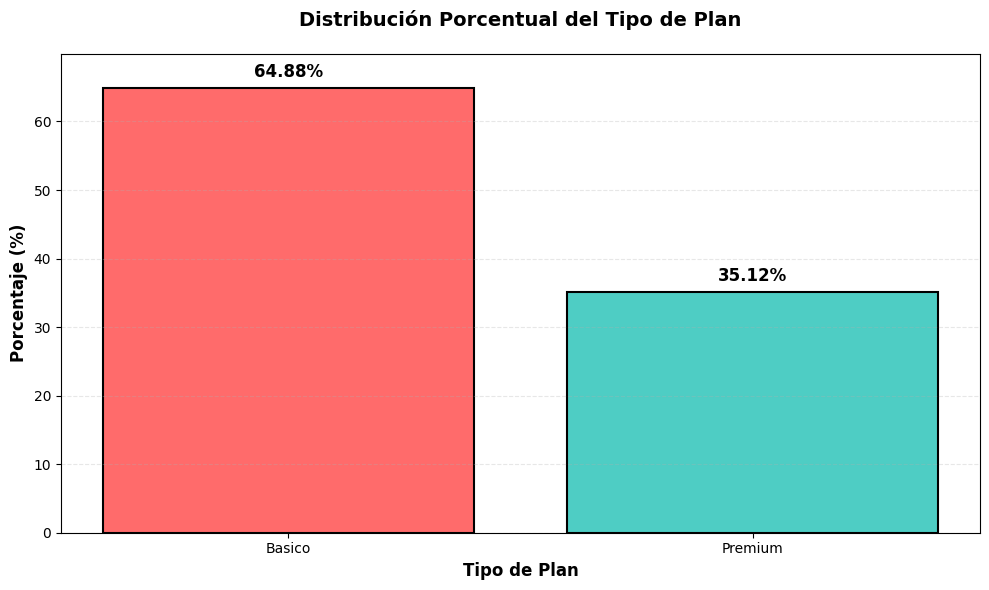

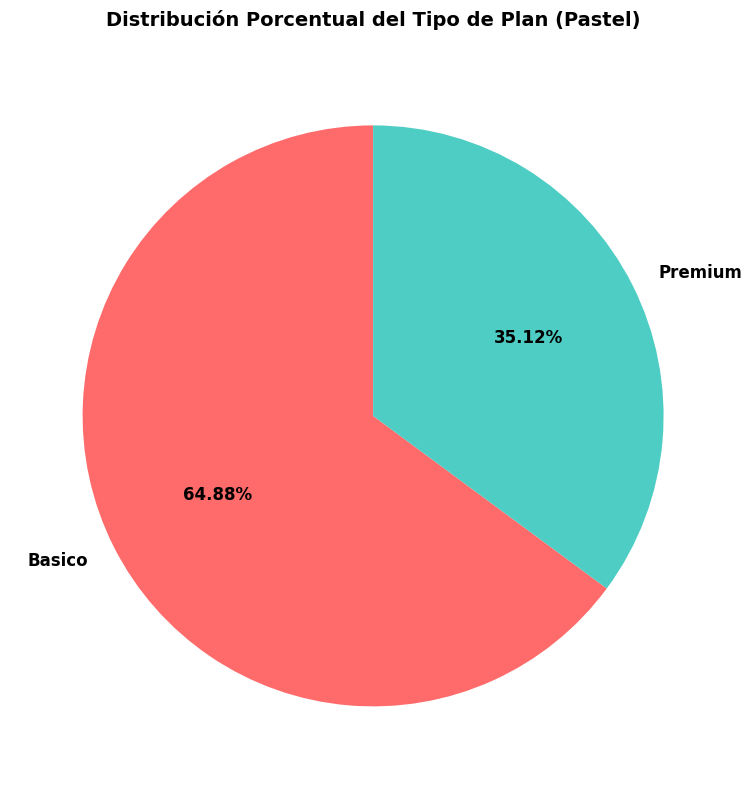

In [70]:
# Distribución porcentual del tipo de plan
# ============================================================
# DISTRIBUCIÓN PORCENTUAL DEL TIPO DE PLAN
# ============================================================

print("="*60)
print("DISTRIBUCIÓN PORCENTUAL DEL TIPO DE PLAN")
print("="*60)

# Contar valores
plan_counts = user_profile['plan'].value_counts()
plan_percentages = user_profile['plan'].value_counts(normalize=True) * 100

# Crear tabla
plan_distribution = pd.DataFrame({
    'Plan': plan_counts.index,
    'Cantidad': plan_counts.values,
    'Porcentaje': plan_percentages.values
})

print("\n" + plan_distribution.to_string(index=False))

# Gráfico de barras
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#FF6B6B', '#4ECDC4']
bars = ax.bar(plan_distribution['Plan'], 
              plan_distribution['Porcentaje'], 
              color=colors, 
              edgecolor='black', 
              linewidth=1.5)

# Agregar porcentajes en las barras
for i, (plan, pct) in enumerate(zip(plan_distribution['Plan'], 
                                      plan_distribution['Porcentaje'])):
    ax.text(i, pct + 1, f'{pct:.2f}%', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Porcentaje (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Tipo de Plan', fontsize=12, fontweight='bold')
ax.set_title('Distribución Porcentual del Tipo de Plan', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, max(plan_distribution['Porcentaje']) + 5)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Gráfico de pastel
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#FF6B6B', '#4ECDC4']
wedges, texts, autotexts = ax.pie(plan_distribution['Cantidad'],
                                    labels=plan_distribution['Plan'],
                                    autopct='%1.2f%%',
                                    colors=colors,
                                    startangle=90,
                                    textprops={'fontsize': 12, 'fontweight': 'bold'})

ax.set_title('Distribución Porcentual del Tipo de Plan (Pastel)', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

No handles with labels found to put in legend.


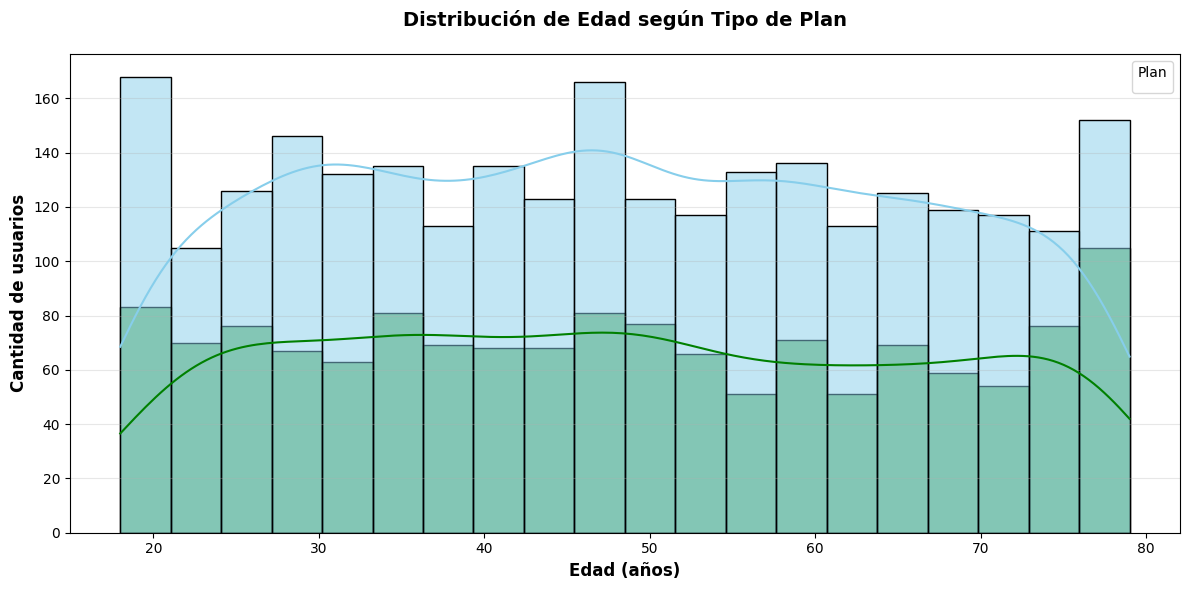

INSIGHT - EDAD
          count       mean        std   min   25%   50%   75%   max
plan                                                               
Basico   2595.0  48.025819  17.537967  18.0  33.0  47.0  63.0  79.0
Premium  1405.0  48.300356  17.973494  18.0  33.0  48.0  64.0  79.0


In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. HISTOGRAMA - EDAD (age)
# ============================================================

plt.figure(figsize=(12, 6))
sns.histplot(data=user_profile, x='age', hue='plan', 
             palette=['skyblue', 'green'], 
             kde=True, bins=20, stat='count')
plt.title('Distribución de Edad según Tipo de Plan', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Edad (años)', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de usuarios', fontsize=12, fontweight='bold')
plt.legend(title='Plan', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Insight
print("="*60)
print("INSIGHT - EDAD")
print("="*60)
age_by_plan = user_profile.groupby('plan')['age'].describe()
print(age_by_plan)


💡Insights:
- Distribución uniforme sin sesgo

No handles with labels found to put in legend.


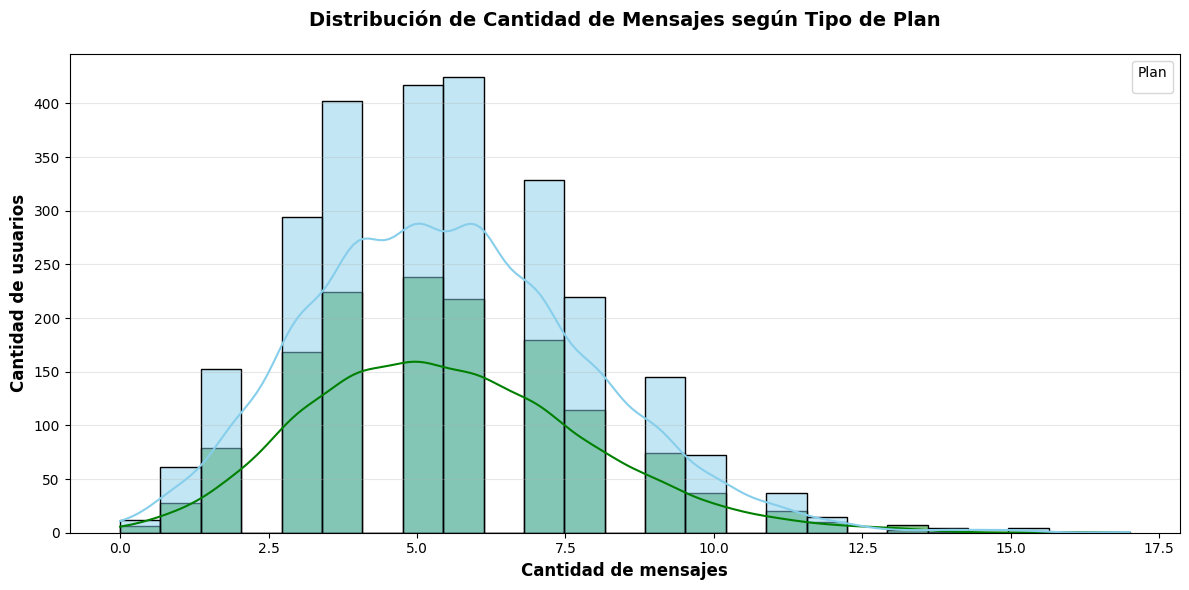


INSIGHT - CANTIDAD DE MENSAJES
          count      mean      std  min  25%  50%  75%   max
plan                                                        
Basico   2594.0  5.527756  2.36282  0.0  4.0  5.0  7.0  17.0
Premium  1405.0  5.518149  2.35109  0.0  4.0  5.0  7.0  16.0


In [79]:

# ============================================================
# 2. HISTOGRAMA - CANTIDAD DE MENSAJES (cant_mensajes)
# ============================================================

plt.figure(figsize=(12, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', 
             palette=['skyblue', 'green'], 
             kde=True, bins=25, stat='count')
plt.title('Distribución de Cantidad de Mensajes según Tipo de Plan', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Cantidad de mensajes', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de usuarios', fontsize=12, fontweight='bold')
plt.legend(title='Plan', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Insight
print("\n" + "="*60)
print("INSIGHT - CANTIDAD DE MENSAJES")
print("="*60)
msg_by_plan = user_profile.groupby('plan')['cant_mensajes'].describe()
print(msg_by_plan)

💡Insights: 
Distribución con sesgo a la derecha

No handles with labels found to put in legend.


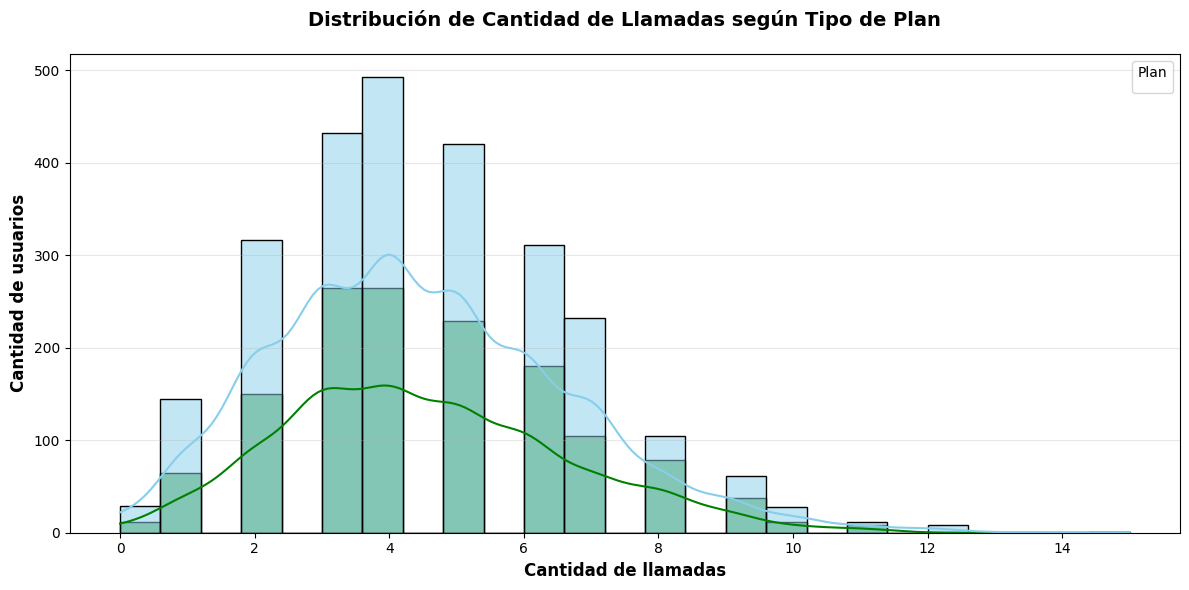


INSIGHT - CANTIDAD DE LLAMADAS
          count      mean       std  min  25%  50%  75%   max
plan                                                         
Basico   2594.0  4.456438  2.168347  0.0  3.0  4.0  6.0  15.0
Premium  1405.0  4.518149  2.099177  0.0  3.0  4.0  6.0  11.0


In [80]:
# ============================================================
# 3. HISTOGRAMA - CANTIDAD DE LLAMADAS (cant_llamadas)
# ============================================================

plt.figure(figsize=(12, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', 
             palette=['skyblue', 'green'], 
             kde=True, bins=25, stat='count')
plt.title('Distribución de Cantidad de Llamadas según Tipo de Plan', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Cantidad de llamadas', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de usuarios', fontsize=12, fontweight='bold')
plt.legend(title='Plan', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Insight
print("\n" + "="*60)
print("INSIGHT - CANTIDAD DE LLAMADAS")
print("="*60)
calls_by_plan = user_profile.groupby('plan')['cant_llamadas'].describe()
print(calls_by_plan)

💡Insights: 
- Distribución con sesgo a la derecha

No handles with labels found to put in legend.


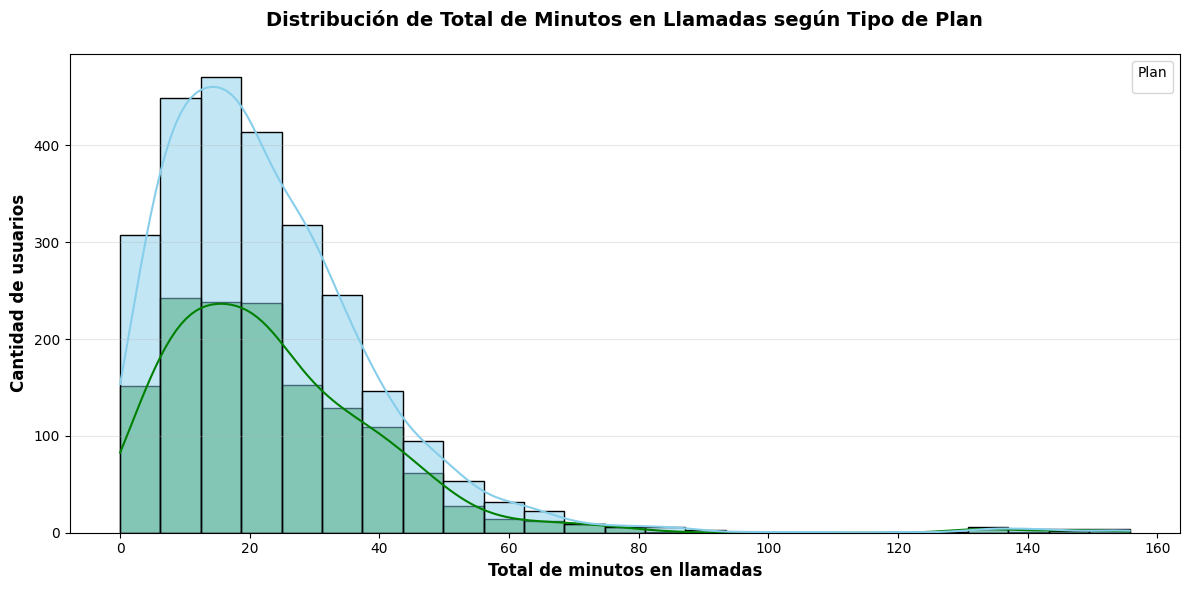


INSIGHT - TOTAL DE MINUTOS EN LLAMADAS
          count       mean        std  min      25%     50%      75%     max
plan                                                                        
Basico   2594.0  22.905436  17.680778  0.0  10.9125  19.535  30.8025  155.69
Premium  1405.0  24.077011  19.018098  0.0  11.5900  20.640  32.5200  153.06


In [81]:
# ============================================================
# 4. HISTOGRAMA - TOTAL DE MINUTOS EN LLAMADAS
# ============================================================

plt.figure(figsize=(12, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', 
             palette=['skyblue', 'green'], 
             kde=True, bins=25, stat='count')
plt.title('Distribución de Total de Minutos en Llamadas según Tipo de Plan', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Total de minutos en llamadas', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de usuarios', fontsize=12, fontweight='bold')
plt.legend(title='Plan', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Insight
print("\n" + "="*60)
print("INSIGHT - TOTAL DE MINUTOS EN LLAMADAS")
print("="*60)
mins_by_plan = user_profile.groupby('plan')['cant_minutos_llamada'].describe()
print(mins_by_plan)

💡Insights: 
- distribución con sesgo a la derecha

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

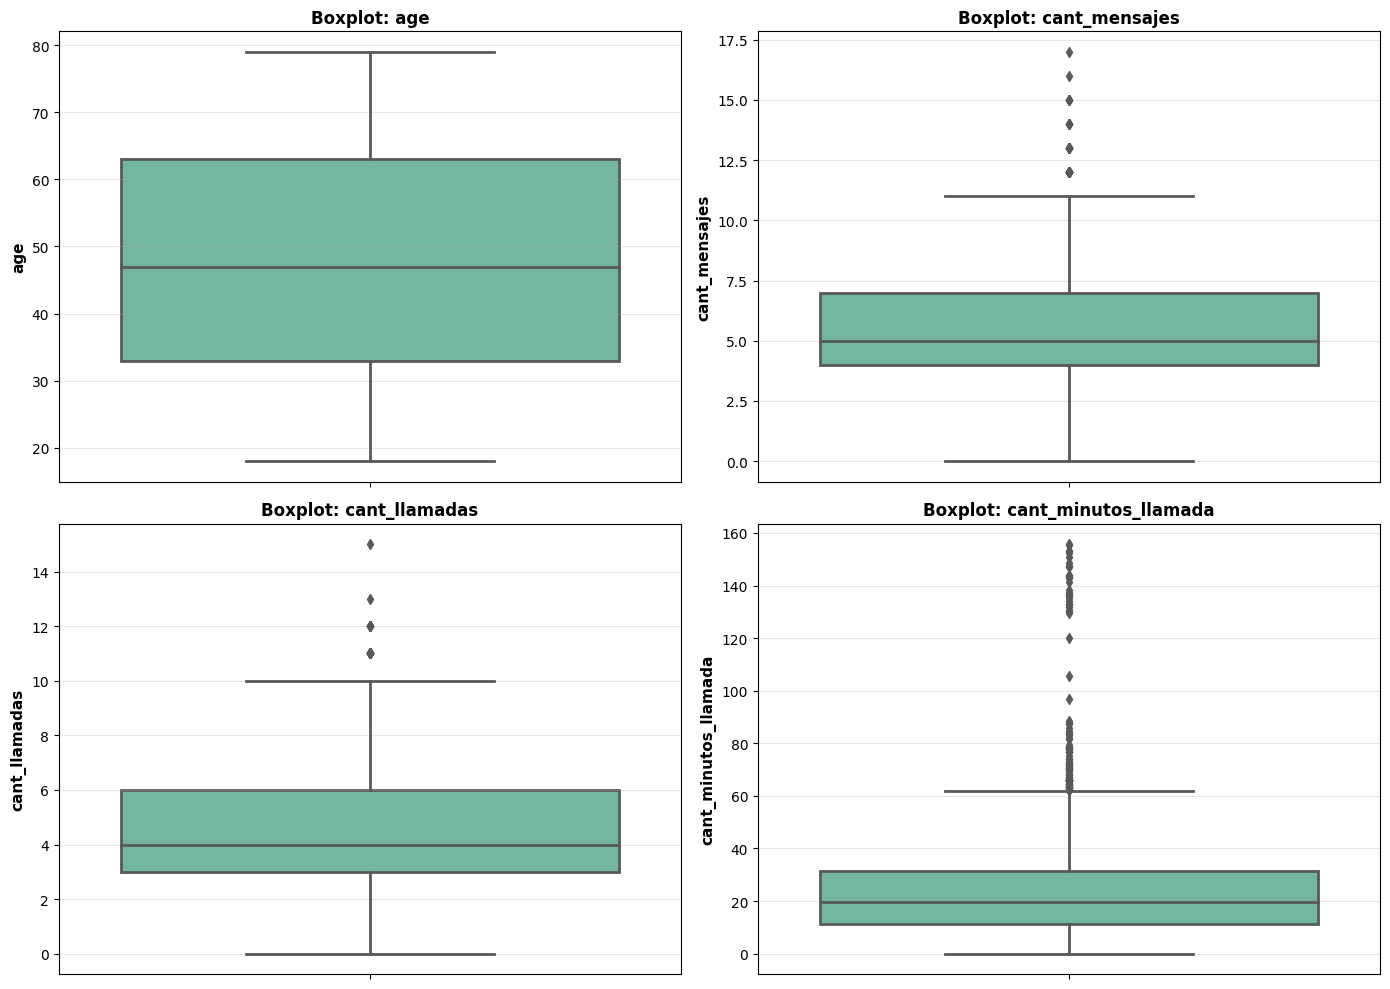

ANÁLISIS DE OUTLIERS

COLUMNA: AGE
Q1 (25%): 33.00
Q3 (75%): 63.00
IQR: 30.00

Límite inferior: -12.00
Límite superior: 108.00

Cantidad de outliers: 0 (0.00%)

✗ NO HAY OUTLIERS en age

COLUMNA: CANT_MENSAJES
Q1 (25%): 4.00
Q3 (75%): 7.00
IQR: 3.00

Límite inferior: -0.50
Límite superior: 11.50

Cantidad de outliers: 46 (1.15%)

✓ SÍ HAY OUTLIERS en cant_mensajes

Valores extremos detectados:
  Mínimo outlier: 12.00
  Máximo outlier: 17.00

COLUMNA: CANT_LLAMADAS
Q1 (25%): 3.00
Q3 (75%): 6.00
IQR: 3.00

Límite inferior: -1.50
Límite superior: 10.50

Cantidad de outliers: 30 (0.75%)

✓ SÍ HAY OUTLIERS en cant_llamadas

Valores extremos detectados:
  Mínimo outlier: 11.00
  Máximo outlier: 15.00

COLUMNA: CANT_MINUTOS_LLAMADA
Q1 (25%): 11.12
Q3 (75%): 31.41
IQR: 20.30

Límite inferior: -19.32
Límite superior: 61.86

Cantidad de outliers: 109 (2.73%)

✓ SÍ HAY OUTLIERS en cant_minutos_llamada

Valores extremos detectados:
  Mínimo outlier: 62.11
  Máximo outlier: 155.69


In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# BOXPLOTS - IDENTIFICACIÓN DE OUTLIERS
# ============================================================

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Crear figura con 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # Convertir a 1D para iterar fácilmente

for idx, columna in enumerate(columnas_numericas):
    sns.boxplot(data=user_profile, y=columna, ax=axes[idx], 
                palette='Set2', linewidth=2)
    axes[idx].set_title(f'Boxplot: {columna}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(columna, fontsize=11, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("="*60)
print("ANÁLISIS DE OUTLIERS")
print("="*60)

# ============================================================
# CÁLCULO DE OUTLIERS USANDO MÉTODO IQR
# ============================================================

for columna in columnas_numericas:
    print(f"\n{'='*60}")
    print(f"COLUMNA: {columna.upper()}")
    print(f"{'='*60}")
    
    # Calcular Q1, Q3, IQR
    Q1 = user_profile[columna].quantile(0.25)
    Q3 = user_profile[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calcular límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Identificar outliers
    outliers = user_profile[
        (user_profile[columna] < limite_inferior) | 
        (user_profile[columna] > limite_superior)
    ]
    
    # Mostrar resultados
    print(f"Q1 (25%): {Q1:.2f}")
    print(f"Q3 (75%): {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"\nLímite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"\nCantidad de outliers: {len(outliers)} ({(len(outliers)/len(user_profile)*100):.2f}%)")
    
    if len(outliers) > 0:
        print(f"\n✓ SÍ HAY OUTLIERS en {columna}")
        print(f"\nValores extremos detectados:")
        print(f"  Mínimo outlier: {outliers[columna].min():.2f}")
        print(f"  Máximo outlier: {outliers[columna].max():.2f}")
    else:
        print(f"\n✗ NO HAY OUTLIERS en {columna}")



💡Insights: 
- Age: no presenta outliers
- cant_mensajes: presenta 46 outliers
- cant_llamadas: presenta 30 outliers
- cant_minutos_llamada:presenta 109 outliers

In [83]:
# ============================================================
# CALCULAR LÍMITES CON EL MÉTODO IQR
# ============================================================

columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Crear diccionario para almacenar los límites
limites_iqr = {}

print("="*70)
print("LÍMITES IQR - MÉTODO DE DETECCIÓN DE OUTLIERS")
print("="*70)

for columna in columnas_limites:
    # Calcular Q1, Q3, IQR
    Q1 = user_profile[columna].quantile(0.25)
    Q3 = user_profile[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calcular límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Almacenar en diccionario
    limites_iqr[columna] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior
    }
    
    # Mostrar resultados
    print(f"\n{columna.upper()}")
    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Límite inferior: {limite_inferior:.2f}")
    print(f"  Límite superior: {limite_superior:.2f}")


# ============================================================
# CREAR DATAFRAME CON LOS LÍMITES
# ============================================================

df_limites = pd.DataFrame(limites_iqr).T
print("\n" + "="*70)
print("TABLA RESUMEN - LÍMITES IQR")
print("="*70)
print(df_limites.round(2))



LÍMITES IQR - MÉTODO DE DETECCIÓN DE OUTLIERS

AGE
  Q1: 33.00
  Q3: 63.00
  IQR: 30.00
  Límite inferior: -12.00
  Límite superior: 108.00

CANT_MENSAJES
  Q1: 4.00
  Q3: 7.00
  IQR: 3.00
  Límite inferior: -0.50
  Límite superior: 11.50

CANT_LLAMADAS
  Q1: 3.00
  Q3: 6.00
  IQR: 3.00
  Límite inferior: -1.50
  Límite superior: 10.50

CANT_MINUTOS_LLAMADA
  Q1: 11.12
  Q3: 31.41
  IQR: 20.30
  Límite inferior: -19.32
  Límite superior: 61.86

TABLA RESUMEN - LÍMITES IQR
                         Q1     Q3   IQR  limite_inferior  limite_superior
age                   33.00  63.00  30.0           -12.00           108.00
cant_mensajes          4.00   7.00   3.0            -0.50            11.50
cant_llamadas          3.00   6.00   3.0            -1.50            10.50
cant_minutos_llamada  11.12  31.42  20.3           -19.32            61.86


ANÁLISIS: ¿MANTENER O ELIMINAR OUTLIERS?

1. ESTADÍSTICAS DESCRIPTIVAS
--------------------------------------------------------------------------------
           age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.00        3999.00        3999.00               3999.00
mean     48.12           5.52           4.48                 23.32
std      17.69           2.36           2.14                 18.17
min      18.00           0.00           0.00                  0.00
25%      33.00           4.00           3.00                 11.12
50%      47.00           5.00           4.00                 19.78
75%      63.00           7.00           6.00                 31.42
max      79.00          17.00          15.00                155.69


2. COMPARACIÓN: LÍMITE SUPERIOR vs MÁXIMO
--------------------------------------------------------------------------------
             Columna  Límite Superior  Máximo  Diferencia  Outliers (N)  Outliers (%)     Acción
                 age   

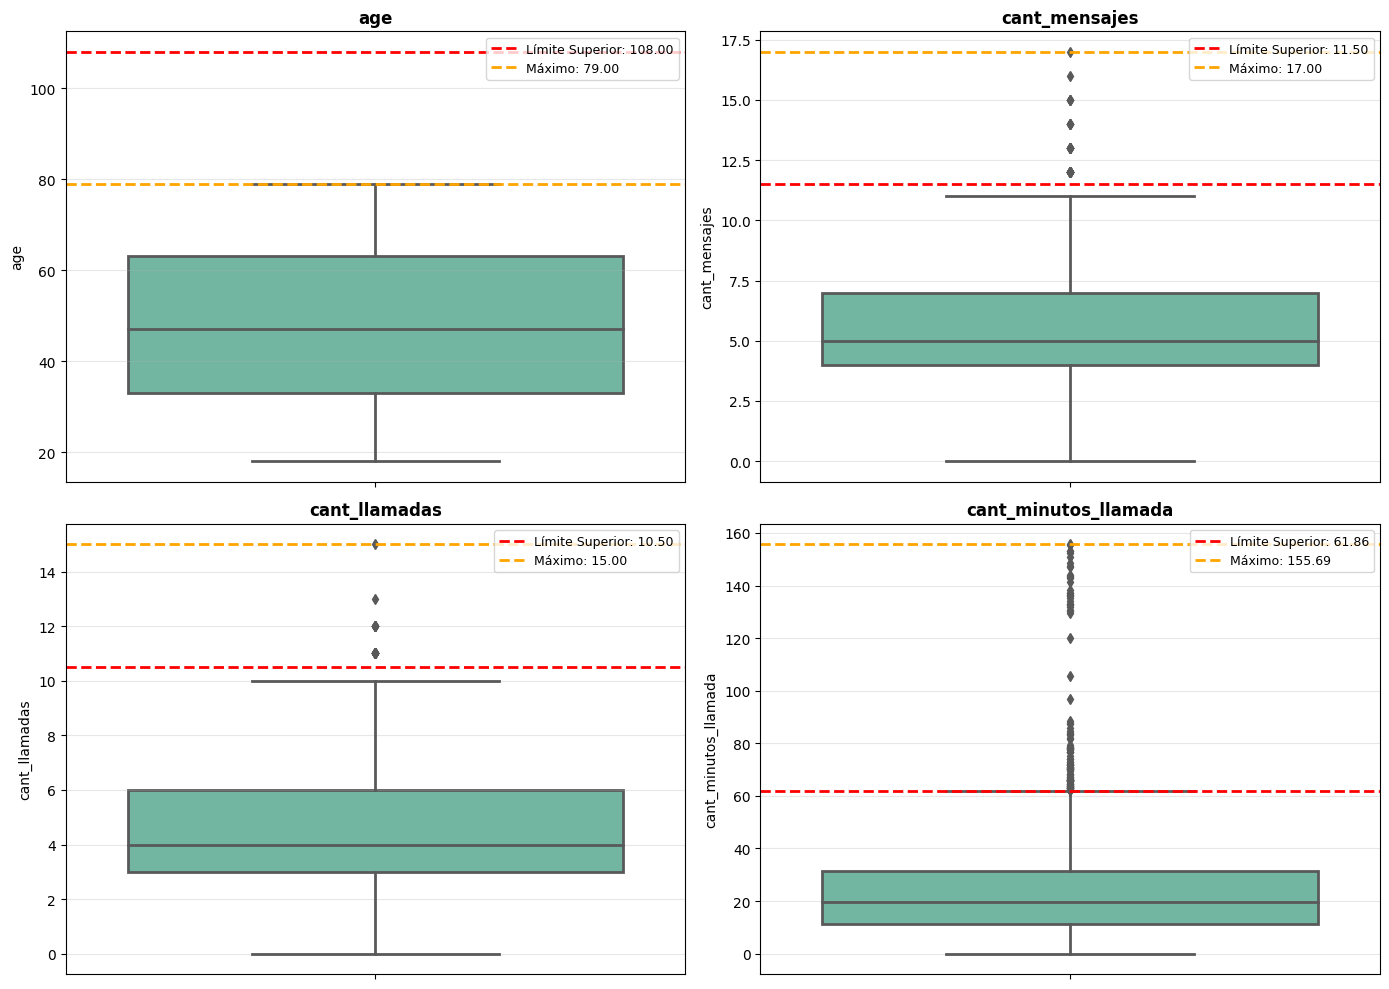

In [85]:

# ============================================================
# COMPARACIÓN: LÍMITES SUPERIORES vs MÁXIMOS
# ============================================================

print("="*80)
print("ANÁLISIS: ¿MANTENER O ELIMINAR OUTLIERS?")
print("="*80)

# Primero, obtener estadísticas descriptivas
print("\n1. ESTADÍSTICAS DESCRIPTIVAS")
print("-"*80)
stats = user_profile[columnas_limites].describe()
print(stats.round(2))

# Luego, comparar límites vs máximos
print("\n\n2. COMPARACIÓN: LÍMITE SUPERIOR vs MÁXIMO")
print("-"*80)

comparacion_data = []

for columna in columnas_limites:
    Q1 = user_profile[columna].quantile(0.25)
    Q3 = user_profile[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    
    maximo = user_profile[columna].max()
    minimo = user_profile[columna].min()
    
    # Contar outliers
    outliers_count = len(user_profile[user_profile[columna] > limite_superior])
    outliers_pct = (outliers_count / len(user_profile)) * 100
    
    comparacion_data.append({
        'Columna': columna,
        'Límite Superior': round(limite_superior, 2),
        'Máximo': round(maximo, 2),
        'Diferencia': round(maximo - limite_superior, 2),
        'Outliers (N)': outliers_count,
        'Outliers (%)': round(outliers_pct, 2),
        'Acción': 'MANTENER ✓' if outliers_pct < 5 else 'REVISAR ⚠️'
    })

df_comparacion = pd.DataFrame(comparacion_data)
print(df_comparacion.to_string(index=False))

# ============================================================
# VISUALIZACIÓN: LÍMITES vs MÁXIMOS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, columna in enumerate(columnas_limites):
    Q1 = user_profile[columna].quantile(0.25)
    Q3 = user_profile[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    maximo = user_profile[columna].max()
    
    # Boxplot
    sns.boxplot(data=user_profile, y=columna, ax=axes[idx], 
                palette='Set2', linewidth=2)
    
    # Agregar líneas de referencia
    axes[idx].axhline(y=limite_superior, color='red', linestyle='--', 
                      linewidth=2, label=f'Límite Superior: {limite_superior:.2f}')
    axes[idx].axhline(y=maximo, color='orange', linestyle='--', 
                      linewidth=2, label=f'Máximo: {maximo:.2f}')
    
    axes[idx].set_title(f'{columna}', fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=9, loc='upper right')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()





💡Insights: 
- cant_mensajes: mantener, los outliers representan menos del 5% de dataset
- cant_llamadas: mantener, los outliers representan menos del 5% de dataset
- cant_minutos_llamada: mantener, los outliers representan menos del 5% de dataset

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

SEGMENTACIÓN DE CLIENTES POR USO

1. PRIMERAS FILAS CON LA NUEVA COLUMNA
----------------------------------------------------------------------
   user_id  cant_llamadas  cant_mensajes  grupo_uso
0    10000            3.0            7.0  Uso medio
1    10001           10.0            5.0   Alto uso
2    10002            2.0            5.0  Uso medio
3    10003            3.0           11.0   Alto uso
4    10004            3.0            4.0   Bajo uso
5    10005            7.0            5.0  Uso medio
6    10006            5.0            3.0  Uso medio
7    10007            5.0            3.0  Uso medio
8    10008            5.0            5.0  Uso medio
9    10009            3.0            5.0  Uso medio


2. DISTRIBUCIÓN DE SEGMENTOS
----------------------------------------------------------------------

Cuenta absoluta:
Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

Porcentaje:
  Uso medio: 73.58%
  Bajo uso: 19.45%
  Alto uso: 6.98%


3. CARAC

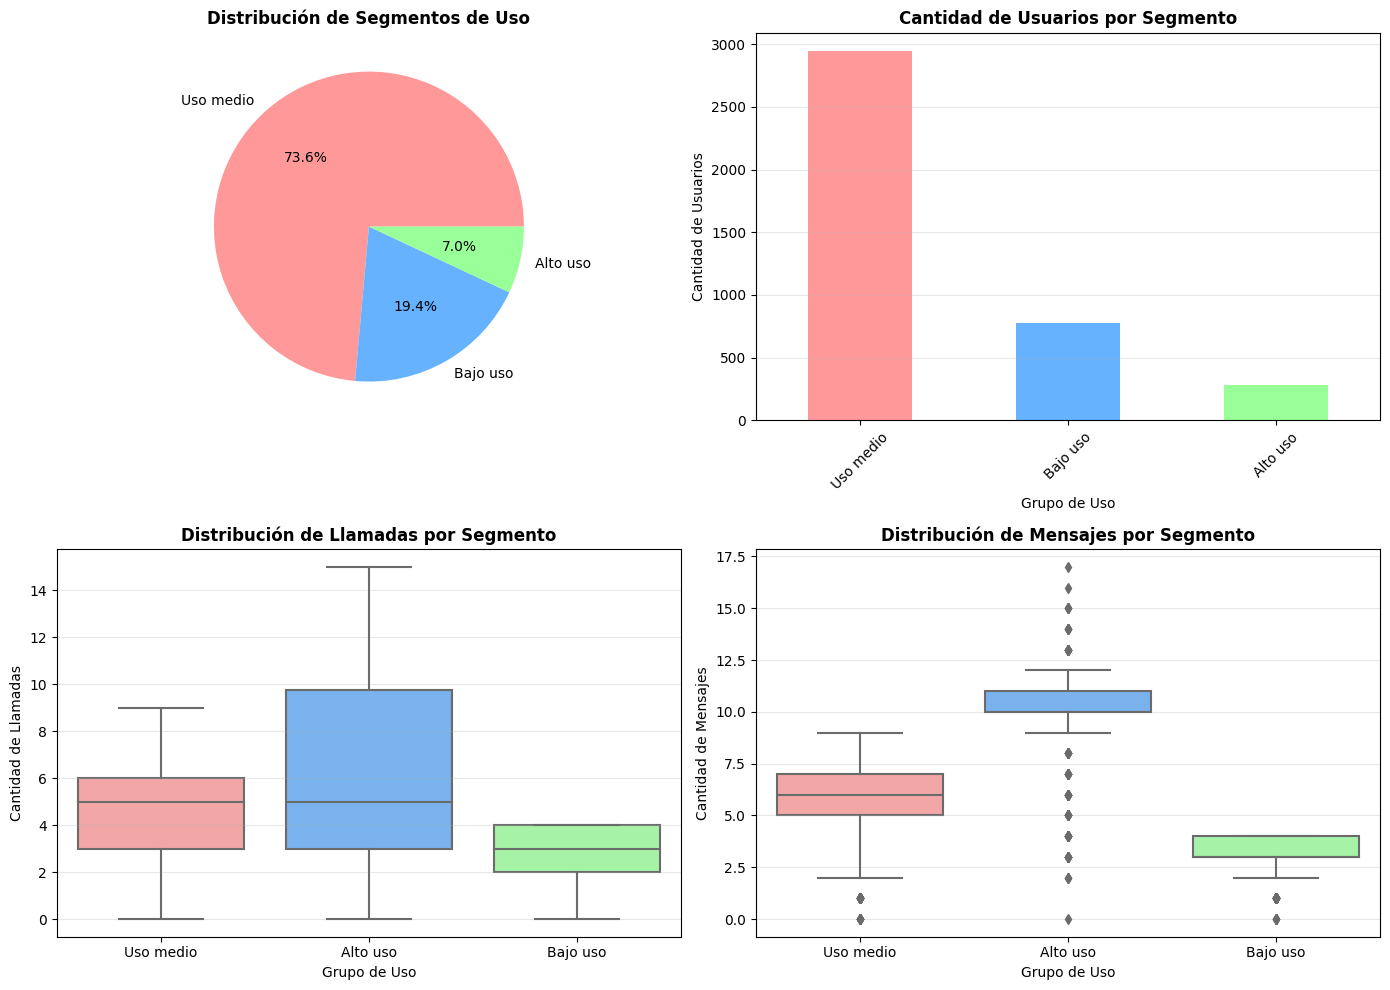



4. TABLA RESUMEN
----------------------------------------------------------------------
           Cantidad  Llamadas_Promedio  Llamadas_Max  Mensajes_Promedio  \
grupo_uso                                                                 
Alto uso        279               5.95          15.0               9.56   
Bajo uso        778               2.81           4.0               3.13   
Uso medio      2943               4.78           9.0               5.78   

           Mensajes_Max  Minutos_Promedio  Edad_Promedio  Premium  
grupo_uso                                                          
Alto uso           17.0             30.15          47.58       93  
Bajo uso            4.0             14.92          48.44      266  
Uso medio           9.0             24.89          48.09     1046  

✓ Columna 'grupo_uso' creada exitosamente en user_profile


In [86]:
# ============================================================
# PASO 6: SEGMENTACIÓN DE CLIENTES
# ============================================================

# 6.1 SEGMENTACIÓN POR USO (Bajo, Medio, Alto)
print("="*70)
print("SEGMENTACIÓN DE CLIENTES POR USO")
print("="*70)

# Crear columna grupo_uso usando np.select para condiciones múltiples
import numpy as np

condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
]

elecciones = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(
    condiciones, 
    elecciones, 
    default='Alto uso'
)

# ============================================================
# VISUALIZAR RESULTADOS
# ============================================================

print("\n1. PRIMERAS FILAS CON LA NUEVA COLUMNA")
print("-"*70)
print(user_profile[['user_id', 'cant_llamadas', 'cant_mensajes', 'grupo_uso']].head(10))

# ============================================================
# ESTADÍSTICAS DE LA SEGMENTACIÓN
# ============================================================

print("\n\n2. DISTRIBUCIÓN DE SEGMENTOS")
print("-"*70)

distribucion = user_profile['grupo_uso'].value_counts()
distribucion_pct = user_profile['grupo_uso'].value_counts(normalize=True) * 100

print("\nCuenta absoluta:")
print(distribucion)

print("\nPorcentaje:")
for grupo, pct in distribucion_pct.items():
    print(f"  {grupo}: {pct:.2f}%")

# ============================================================
# CARACTERÍSTICAS DE CADA SEGMENTO
# ============================================================

print("\n\n3. CARACTERÍSTICAS POR SEGMENTO")
print("-"*70)

for grupo in ['Bajo uso', 'Uso medio', 'Alto uso']:
    print(f"\n{grupo.upper()}")
    print("-"*70)
    
    grupo_data = user_profile[user_profile['grupo_uso'] == grupo]
    
    print(f"  Cantidad: {len(grupo_data)} usuarios ({(len(grupo_data)/len(user_profile)*100):.2f}%)")
    print(f"  Llamadas - Media: {grupo_data['cant_llamadas'].mean():.2f}, "
          f"Máximo: {grupo_data['cant_llamadas'].max():.0f}")
    print(f"  Mensajes - Media: {grupo_data['cant_mensajes'].mean():.2f}, "
          f"Máximo: {grupo_data['cant_mensajes'].max():.0f}")
    print(f"  Minutos - Media: {grupo_data['cant_minutos_llamada'].mean():.2f}, "
          f"Máximo: {grupo_data['cant_minutos_llamada'].max():.0f}")
    print(f"  Edad - Media: {grupo_data['age'].mean():.1f} años")
    print(f"  Plan Basico: {len(grupo_data[grupo_data['plan']=='Basico'])} usuarios")
    print(f"  Plan Premium: {len(grupo_data[grupo_data['plan']=='Premium'])} usuarios")

# ============================================================
# VISUALIZACIÓN: GRÁFICOS DE SEGMENTACIÓN
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Pie Chart - Distribución de segmentos
ax1 = axes[0, 0]
distribucion.plot(kind='pie', ax=ax1, autopct='%1.1f%%', 
                  colors=['#FF9999', '#66B2FF', '#99FF99'])
ax1.set_title('Distribución de Segmentos de Uso', fontsize=12, fontweight='bold')
ax1.set_ylabel('')

# 2. Bar Chart - Cantidad de usuarios por segmento
ax2 = axes[0, 1]
distribucion.plot(kind='bar', ax=ax2, color=['#FF9999', '#66B2FF', '#99FF99'])
ax2.set_title('Cantidad de Usuarios por Segmento', fontsize=12, fontweight='bold')
ax2.set_xlabel('Grupo de Uso')
ax2.set_ylabel('Cantidad de Usuarios')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# 3. Box Plot - Llamadas por segmento
ax3 = axes[1, 0]
sns.boxplot(data=user_profile, x='grupo_uso', y='cant_llamadas', ax=ax3,
            palette=['#FF9999', '#66B2FF', '#99FF99'])
ax3.set_title('Distribución de Llamadas por Segmento', fontsize=12, fontweight='bold')
ax3.set_xlabel('Grupo de Uso')
ax3.set_ylabel('Cantidad de Llamadas')
ax3.grid(axis='y', alpha=0.3)

# 4. Box Plot - Mensajes por segmento
ax4 = axes[1, 1]
sns.boxplot(data=user_profile, x='grupo_uso', y='cant_mensajes', ax=ax4,
            palette=['#FF9999', '#66B2FF', '#99FF99'])
ax4.set_title('Distribución de Mensajes por Segmento', fontsize=12, fontweight='bold')
ax4.set_xlabel('Grupo de Uso')
ax4.set_ylabel('Cantidad de Mensajes')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# TABLA RESUMEN DE SEGMENTACIÓN
# ============================================================

print("\n\n4. TABLA RESUMEN")
print("-"*70)

resumen_segmentacion = user_profile.groupby('grupo_uso').agg({
    'user_id': 'count',
    'cant_llamadas': ['mean', 'max'],
    'cant_mensajes': ['mean', 'max'],
    'cant_minutos_llamada': 'mean',
    'age': 'mean',
    'plan': lambda x: (x == 'Premium').sum()
}).round(2)

resumen_segmentacion.columns = ['Cantidad', 'Llamadas_Promedio', 'Llamadas_Max', 
                                'Mensajes_Promedio', 'Mensajes_Max', 
                                'Minutos_Promedio', 'Edad_Promedio', 'Premium']

print(resumen_segmentacion)

print("\n✓ Columna 'grupo_uso' creada exitosamente en user_profile")


In [87]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

SEGMENTACIÓN DE CLIENTES POR EDAD

1. PRIMERAS FILAS CON LA NUEVA COLUMNA
----------------------------------------------------------------------
    user_id   age    grupo_edad
0     10000  38.0        Adulto
1     10001  53.0        Adulto
2     10002  57.0        Adulto
3     10003  69.0  Adulto Mayor
4     10004  63.0  Adulto Mayor
5     10005  61.0  Adulto Mayor
6     10006  39.0        Adulto
7     10007  70.0  Adulto Mayor
8     10008  76.0  Adulto Mayor
9     10009  47.0        Adulto
10    10010  67.0  Adulto Mayor
11    10011  60.0  Adulto Mayor
12    10012  47.0        Adulto
13    10013  78.0  Adulto Mayor
14    10014  77.0  Adulto Mayor


2. DISTRIBUCIÓN DE SEGMENTOS POR EDAD
----------------------------------------------------------------------

Cuenta absoluta:
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

Porcentaje:
  Adulto: 50.45%
  Adulto Mayor: 30.55%
  Joven: 19.00%


3. CARACTERÍSTICAS POR GRUPO DE EDAD
------------

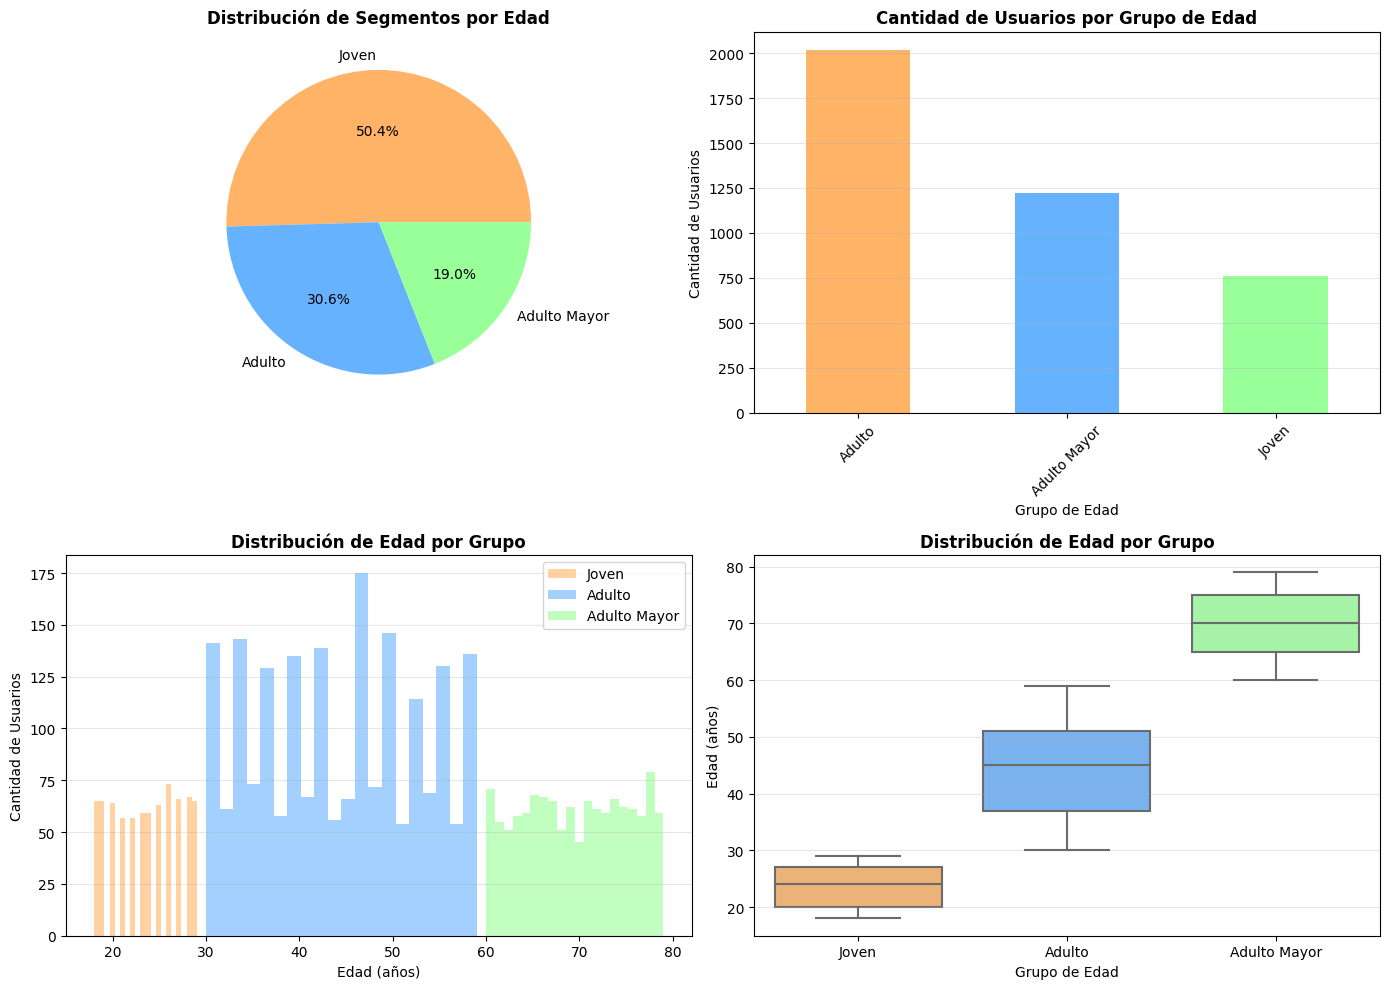



4. TABLA RESUMEN
----------------------------------------------------------------------
              Cantidad  Edad_Promedio  Edad_Min  Edad_Max  Llamadas_Promedio  \
grupo_edad                                                                     
Adulto            2018          44.35      30.0      59.0               4.48   
Adulto Mayor      1222          69.62      60.0      79.0               4.50   
Joven              760          23.59      18.0      29.0               4.43   

              Mensajes_Promedio  Minutos_Promedio  Premium  
grupo_edad                                                  
Adulto                     5.55             23.00      693  
Adulto Mayor               5.49             23.58      438  
Joven                      5.52             23.75      274  


5. ANÁLISIS CRUZADO: EDAD vs PLAN
----------------------------------------------------------------------

Cuenta absoluta:
plan          Basico  Premium   All
grupo_edad                         
Adulto 

In [90]:
# Crear columna grupo_edad
# ============================================================
# PASO 6.2: SEGMENTACIÓN DE CLIENTES POR EDAD
# ============================================================

print("="*70)
print("SEGMENTACIÓN DE CLIENTES POR EDAD")
print("="*70)

# Crear columna grupo_edad usando np.select
condiciones_edad = [
    user_profile['age'] < 30,
    user_profile['age'] < 60,
]

elecciones_edad = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(
    condiciones_edad, 
    elecciones_edad, 
    default='Adulto Mayor'
)

# ============================================================
# VISUALIZAR RESULTADOS
# ============================================================

print("\n1. PRIMERAS FILAS CON LA NUEVA COLUMNA")
print("-"*70)
print(user_profile[['user_id', 'age', 'grupo_edad']].head(15))

# ============================================================
# ESTADÍSTICAS DE LA SEGMENTACIÓN POR EDAD
# ============================================================

print("\n\n2. DISTRIBUCIÓN DE SEGMENTOS POR EDAD")
print("-"*70)

distribucion_edad = user_profile['grupo_edad'].value_counts().sort_index()
distribucion_edad_pct = user_profile['grupo_edad'].value_counts(normalize=True) * 100

print("\nCuenta absoluta:")
print(distribucion_edad)

print("\nPorcentaje:")
for grupo, pct in distribucion_edad_pct.items():
    print(f"  {grupo}: {pct:.2f}%")

# ============================================================
# CARACTERÍSTICAS DE CADA SEGMENTO POR EDAD
# ============================================================

print("\n\n3. CARACTERÍSTICAS POR GRUPO DE EDAD")
print("-"*70)

for grupo in ['Joven', 'Adulto', 'Adulto Mayor']:
    print(f"\n{grupo.upper()}")
    print("-"*70)
    
    grupo_data = user_profile[user_profile['grupo_edad'] == grupo]
    
    print(f"  Cantidad: {len(grupo_data)} usuarios ({(len(grupo_data)/len(user_profile)*100):.2f}%)")
    print(f"  Edad - Media: {grupo_data['age'].mean():.1f}, "
          f"Rango: {grupo_data['age'].min():.0f} - {grupo_data['age'].max():.0f}")
    print(f"  Llamadas - Media: {grupo_data['cant_llamadas'].mean():.2f}, "
          f"Máximo: {grupo_data['cant_llamadas'].max():.0f}")
    print(f"  Mensajes - Media: {grupo_data['cant_mensajes'].mean():.2f}, "
          f"Máximo: {grupo_data['cant_mensajes'].max():.0f}")
    print(f"  Minutos - Media: {grupo_data['cant_minutos_llamada'].mean():.2f}, "
          f"Máximo: {grupo_data['cant_minutos_llamada'].max():.0f}")
    print(f"  Plan Basico: {len(grupo_data[grupo_data['plan']=='Basico'])} usuarios ({(len(grupo_data[grupo_data['plan']=='Basico'])/len(grupo_data)*100):.2f}%)")
    print(f"  Plan Premium: {len(grupo_data[grupo_data['plan']=='Premium'])} usuarios ({(len(grupo_data[grupo_data['plan']=='Premium'])/len(grupo_data)*100):.2f}%)")

# ============================================================
# VISUALIZACIÓN: GRÁFICOS DE SEGMENTACIÓN POR EDAD
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Pie Chart - Distribución de segmentos por edad
ax1 = axes[0, 0]
distribucion_edad.plot(kind='pie', ax=ax1, autopct='%1.1f%%', 
                       colors=['#FFB366', '#66B2FF', '#99FF99'],
                       labels=['Joven', 'Adulto', 'Adulto Mayor'])
ax1.set_title('Distribución de Segmentos por Edad', fontsize=12, fontweight='bold')
ax1.set_ylabel('')

# 2. Bar Chart - Cantidad de usuarios por grupo de edad
ax2 = axes[0, 1]
distribucion_edad.plot(kind='bar', ax=ax2, color=['#FFB366', '#66B2FF', '#99FF99'])
ax2.set_title('Cantidad de Usuarios por Grupo de Edad', fontsize=12, fontweight='bold')
ax2.set_xlabel('Grupo de Edad')
ax2.set_ylabel('Cantidad de Usuarios')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# 3. Histogram - Distribución de edad con segmentación
ax3 = axes[1, 0]
for grupo, color in zip(['Joven', 'Adulto', 'Adulto Mayor'], 
                        ['#FFB366', '#66B2FF', '#99FF99']):
    grupo_data = user_profile[user_profile['grupo_edad'] == grupo]['age']
    ax3.hist(grupo_data, bins=20, alpha=0.6, label=grupo, color=color)
ax3.set_title('Distribución de Edad por Grupo', fontsize=12, fontweight='bold')
ax3.set_xlabel('Edad (años)')
ax3.set_ylabel('Cantidad de Usuarios')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Box Plot - Edad por grupo
ax4 = axes[1, 1]
sns.boxplot(data=user_profile, x='grupo_edad', y='age', ax=ax4,
            palette=['#FFB366', '#66B2FF', '#99FF99'],
            order=['Joven', 'Adulto', 'Adulto Mayor'])
ax4.set_title('Distribución de Edad por Grupo', fontsize=12, fontweight='bold')
ax4.set_xlabel('Grupo de Edad')
ax4.set_ylabel('Edad (años)')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# TABLA RESUMEN DE SEGMENTACIÓN POR EDAD
# ============================================================

print("\n\n4. TABLA RESUMEN")
print("-"*70)

resumen_edad = user_profile.groupby('grupo_edad', observed=True).agg({
    'user_id': 'count',
    'age': ['mean', 'min', 'max'],
    'cant_llamadas': 'mean',
    'cant_mensajes': 'mean',
    'cant_minutos_llamada': 'mean',
    'plan': lambda x: (x == 'Premium').sum()
}).round(2)

resumen_edad.columns = ['Cantidad', 'Edad_Promedio', 'Edad_Min', 'Edad_Max',
                        'Llamadas_Promedio', 'Mensajes_Promedio', 
                        'Minutos_Promedio', 'Premium']

print(resumen_edad)

# ============================================================
# ANÁLISIS CRUZADO: EDAD vs PLAN
# ============================================================

print("\n\n5. ANÁLISIS CRUZADO: EDAD vs PLAN")
print("-"*70)

crosstab_edad_plan = pd.crosstab(
    user_profile['grupo_edad'], 
    user_profile['plan'], 
    margins=True
)

print("\nCuenta absoluta:")
print(crosstab_edad_plan)

# Porcentaje
crosstab_pct = pd.crosstab(
    user_profile['grupo_edad'], 
    user_profile['plan'], 
    normalize='index'
) * 100

print("\nPorcentaje (por fila):")
print(crosstab_pct.round(2))

print("\n Columna 'grupo_edad' creada exitosamente en user_profile")


In [91]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

VISUALIZACIÓN DE LA SEGMENTACIÓN DE CLIENTES


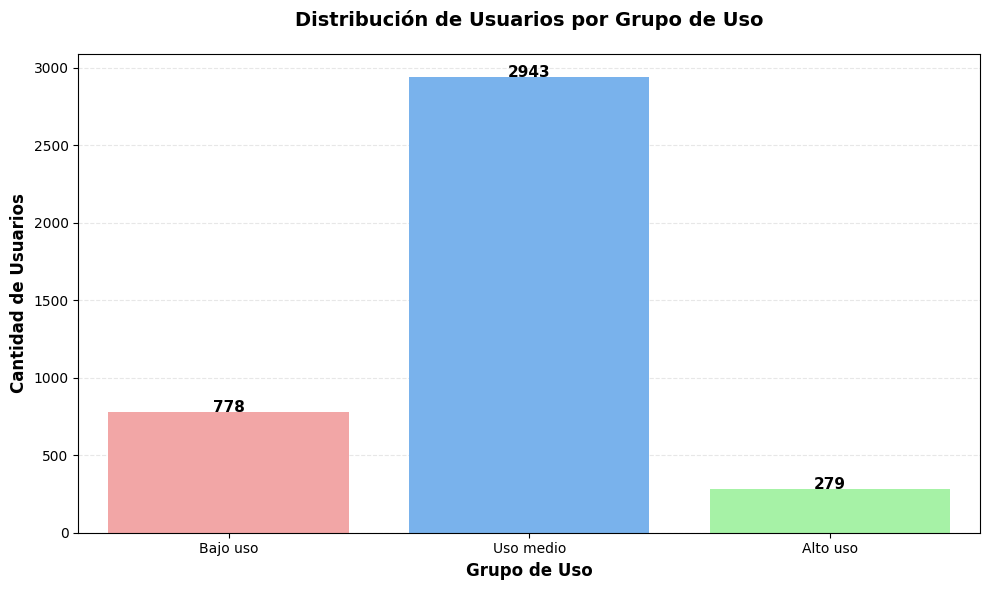

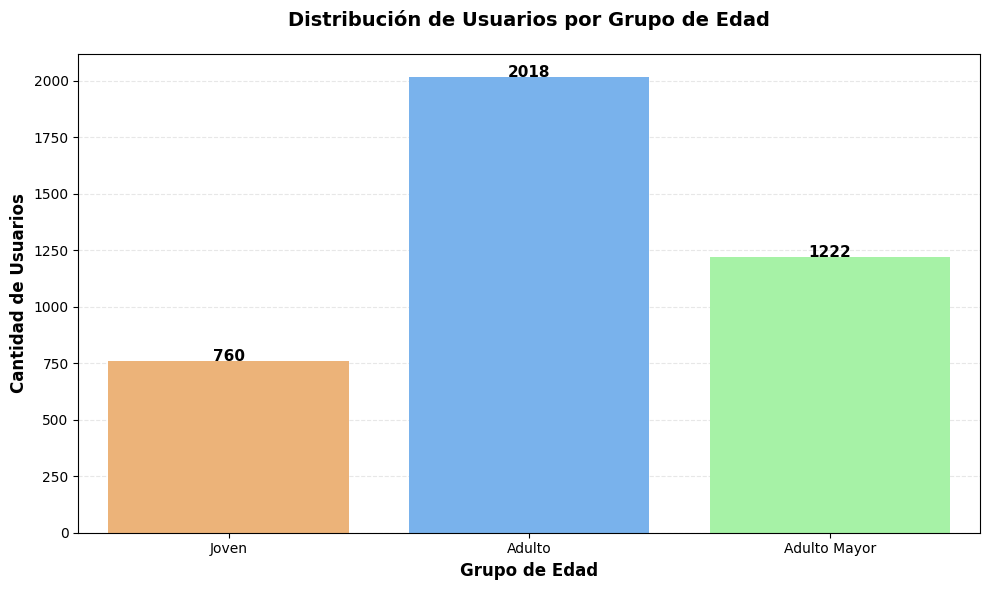

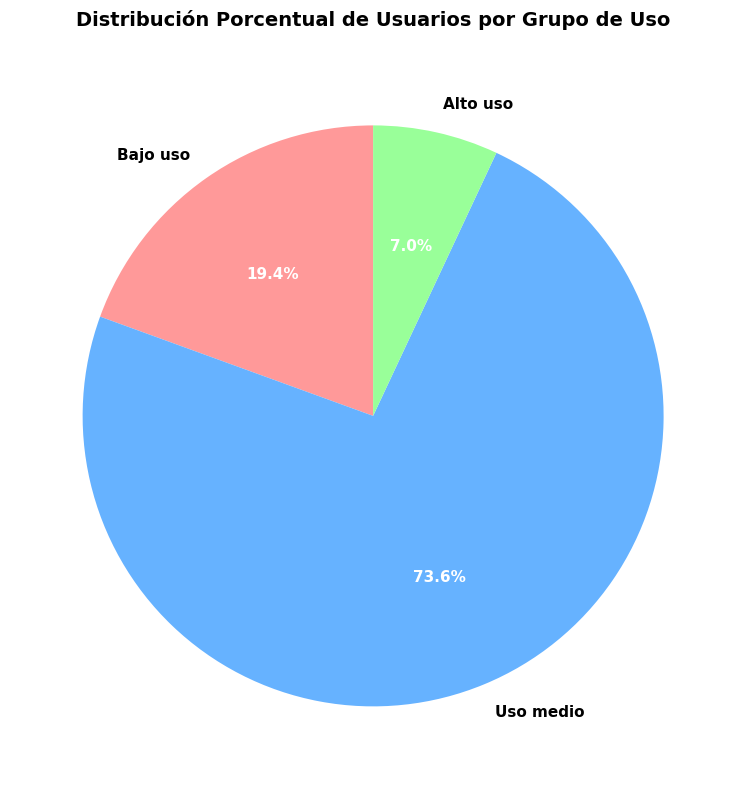

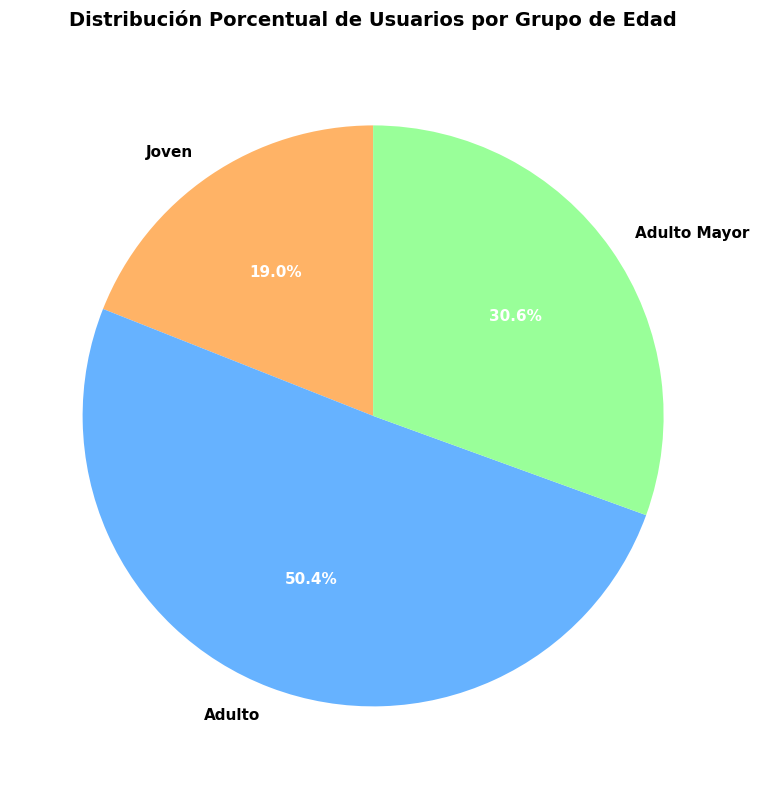

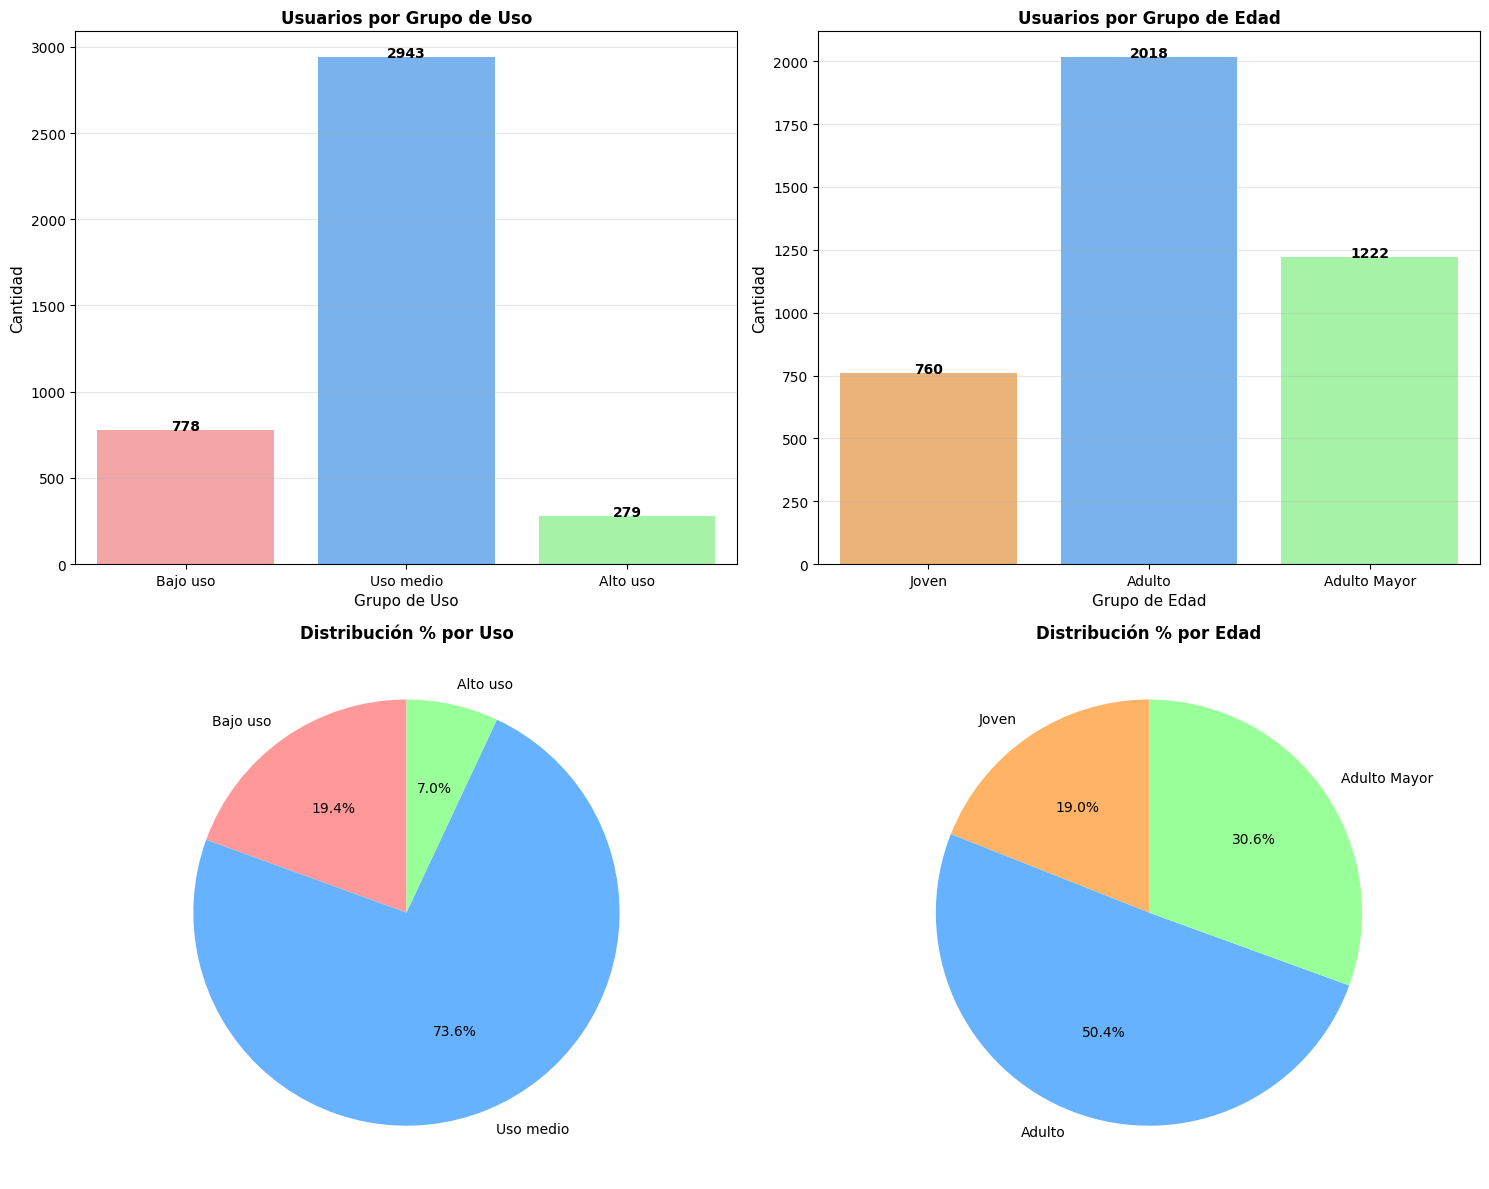



RESUMEN FINAL DE SEGMENTACIÓN

 SEGMENTACIÓN POR USO
----------------------------------------------------------------------
Uso medio           :  2943 usuarios (73.58%)
Bajo uso            :   778 usuarios (19.45%)
Alto uso            :   279 usuarios ( 6.98%)

 SEGMENTACIÓN POR EDAD
----------------------------------------------------------------------
Adulto              :  2018 usuarios (50.45%)
Adulto Mayor        :  1222 usuarios (30.55%)
Joven               :   760 usuarios (19.00%)

TOTAL               :  4000 usuarios

✓ Visualizaciones completadas exitosamente


In [93]:
# ============================================================
# PASO 6.3: VISUALIZACIÓN DE LA SEGMENTACIÓN DE CLIENTES
# (VERSIÓN COMPATIBLE)
# ============================================================

print("="*70)
print("VISUALIZACIÓN DE LA SEGMENTACIÓN DE CLIENTES")
print("="*70)

# ============================================================
# GRÁFICO 1: SEGMENTACIÓN POR USO
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Contar usuarios por grupo de uso
grupo_uso_counts = user_profile['grupo_uso'].value_counts()

# Crear countplot
sns.countplot(data=user_profile, x='grupo_uso', ax=ax, 
              palette=['#FF9999', '#66B2FF', '#99FF99'],
              order=['Bajo uso', 'Uso medio', 'Alto uso'])

# Agregar título y etiquetas
ax.set_title('Distribución de Usuarios por Grupo de Uso', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Grupo de Uso', fontsize=12, fontweight='bold')
ax.set_ylabel('Cantidad de Usuarios', fontsize=12, fontweight='bold')

# Agregar valores en las barras (MÉTODO COMPATIBLE)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height,
            '{:1.0f}'.format(height),
            ha="center", fontsize=11, fontweight='bold')

# Agregar grid
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# ============================================================
# GRÁFICO 2: SEGMENTACIÓN POR EDAD
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

sns.countplot(data=user_profile, x='grupo_edad', ax=ax, 
              palette=['#FFB366', '#66B2FF', '#99FF99'],
              order=['Joven', 'Adulto', 'Adulto Mayor'])

ax.set_title('Distribución de Usuarios por Grupo de Edad', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Grupo de Edad', fontsize=12, fontweight='bold')
ax.set_ylabel('Cantidad de Usuarios', fontsize=12, fontweight='bold')

# Agregar valores en las barras (MÉTODO COMPATIBLE)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height,
            '{:1.0f}'.format(height),
            ha="center", fontsize=11, fontweight='bold')

ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# ============================================================
# GRÁFICO 3: SEGMENTACIÓN POR USO CON PORCENTAJES (PIE CHART)
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

grupo_uso_counts = user_profile['grupo_uso'].value_counts()
orden_uso = ['Bajo uso', 'Uso medio', 'Alto uso']
grupo_uso_counts = grupo_uso_counts.reindex(orden_uso)

colores_uso = ['#FF9999', '#66B2FF', '#99FF99']

wedges, texts, autotexts = ax.pie(grupo_uso_counts, 
                                    labels=grupo_uso_counts.index,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    colors=colores_uso,
                                    textprops={'fontsize': 11, 'fontweight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax.set_title('Distribución Porcentual de Usuarios por Grupo de Uso', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# ============================================================
# GRÁFICO 4: SEGMENTACIÓN POR EDAD CON PORCENTAJES (PIE CHART)
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

grupo_edad_counts = user_profile['grupo_edad'].value_counts()
orden_edad = ['Joven', 'Adulto', 'Adulto Mayor']
grupo_edad_counts = grupo_edad_counts.reindex(orden_edad)

colores_edad = ['#FFB366', '#66B2FF', '#99FF99']

wedges, texts, autotexts = ax.pie(grupo_edad_counts, 
                                    labels=grupo_edad_counts.index,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    colors=colores_edad,
                                    textprops={'fontsize': 11, 'fontweight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax.set_title('Distribución Porcentual de Usuarios por Grupo de Edad', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# ============================================================
# GRÁFICO 5: COMPARACIÓN DE SEGMENTACIÓN (2x2)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Countplot - Uso
ax1 = axes[0, 0]
sns.countplot(data=user_profile, x='grupo_uso', ax=ax1, 
              palette=['#FF9999', '#66B2FF', '#99FF99'],
              order=['Bajo uso', 'Uso medio', 'Alto uso'])
ax1.set_title('Usuarios por Grupo de Uso', fontsize=12, fontweight='bold')
ax1.set_xlabel('Grupo de Uso', fontsize=11)
ax1.set_ylabel('Cantidad', fontsize=11)

# Agregar valores (MÉTODO COMPATIBLE)
for p in ax1.patches:
    height = p.get_height()
    ax1.text(p.get_x() + p.get_width()/2., height,
            '{:1.0f}'.format(height),
            ha="center", fontsize=10, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Countplot - Edad
ax2 = axes[0, 1]
sns.countplot(data=user_profile, x='grupo_edad', ax=ax2, 
              palette=['#FFB366', '#66B2FF', '#99FF99'],
              order=['Joven', 'Adulto', 'Adulto Mayor'])
ax2.set_title('Usuarios por Grupo de Edad', fontsize=12, fontweight='bold')
ax2.set_xlabel('Grupo de Edad', fontsize=11)
ax2.set_ylabel('Cantidad', fontsize=11)

# Agregar valores (MÉTODO COMPATIBLE)
for p in ax2.patches:
    height = p.get_height()
    ax2.text(p.get_x() + p.get_width()/2., height,
            '{:1.0f}'.format(height),
            ha="center", fontsize=10, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Pie - Uso
ax3 = axes[1, 0]
grupo_uso_counts = user_profile['grupo_uso'].value_counts().reindex(['Bajo uso', 'Uso medio', 'Alto uso'])
ax3.pie(grupo_uso_counts, labels=grupo_uso_counts.index, autopct='%1.1f%%',
        colors=['#FF9999', '#66B2FF', '#99FF99'], startangle=90)
ax3.set_title('Distribución % por Uso', fontsize=12, fontweight='bold')

# 4. Pie - Edad
ax4 = axes[1, 1]
grupo_edad_counts = user_profile['grupo_edad'].value_counts().reindex(['Joven', 'Adulto', 'Adulto Mayor'])
ax4.pie(grupo_edad_counts, labels=grupo_edad_counts.index, autopct='%1.1f%%',
        colors=['#FFB366', '#66B2FF', '#99FF99'], startangle=90)
ax4.set_title('Distribución % por Edad', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# RESUMEN DE SEGMENTACIÓN
# ============================================================

print("\n\n" + "="*70)
print("RESUMEN FINAL DE SEGMENTACIÓN")
print("="*70)

print("\n SEGMENTACIÓN POR USO")
print("-"*70)
seg_uso = user_profile['grupo_uso'].value_counts()
for grupo, count in seg_uso.items():
    pct = (count / len(user_profile)) * 100
    print(f"{grupo:20s}: {count:5d} usuarios ({pct:5.2f}%)")

print("\n SEGMENTACIÓN POR EDAD")
print("-"*70)
seg_edad = user_profile['grupo_edad'].value_counts()
for grupo, count in seg_edad.items():
    pct = (count / len(user_profile)) * 100
    print(f"{grupo:20s}: {count:5d} usuarios ({pct:5.2f}%)")

print(f"\n{'TOTAL':20s}: {len(user_profile):5d} usuarios")
print("\n✓ Visualizaciones completadas exitosamente")




---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

La columna age tenía valores inválidos como -999, lo que afecta el promedio. Representaba una pequeña parte del dataset pero distorsionaba los resultados.

La columna city tenía aproximadamente 11% de valores faltantes, lo cual es manejable.

La columna churn_date tenía 88% de valores nulos, pero esto no es un error: indica que esos usuarios siguen activos.

En el dataset de uso, duration y length tenían muchos valores nulos (55% y 45%), pero esto es normal porque dependen del tipo de evento (llamada o mensaje).

Por edad:

Jóvenes (<30 años): usan más mensajes que llamadas

Adultos (30–60 años): uso equilibrado

Adultos mayores (>60): menor uso general

Por nivel de uso:

Bajo uso: pocos mensajes y llamadas

Uso medio: comportamiento estándar

Alto uso: gran cantidad de llamadas y mensajes

Los usuarios jóvenes tienden a comunicarse más por mensajes, mientras que los adultos usan más llamadas.

Los clientes de alto uso son los más valiosos porque consumen más servicios.

Especialmente los de plan Premium, ya que probablemente generan más ingresos.

También los usuarios con alto uso constante representan clientes leales.

Se detectaron usuarios con un número muy alto de mensajes, llamadas y minutos.

Estos representan menos del 5% del total, pero tienen un comportamiento intensivo.

Esto implica que:

Son usuarios “heavy users”

Pueden estar pagando más o necesitando mejores planes

Recomendaciones para el negocio:

Crear planes especiales para usuarios de alto uso con beneficios adicionales

Ofrecer paquetes más económicos para usuarios de bajo uso

Diseñar planes enfocados en jóvenes con más mensajes incluidos

Mantener y fidelizar a clientes Premium, ya que son los más rentables

Analizar a los usuarios extremos para evitar saturación o mejorar su experiencia

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`